# EX07. SentencePiece를 활용한 한국어 감성분석

## 프로젝트 목표

네이버 영화리뷰 감성분석(NSMC) 데이터에 SentencePiece 기반 Subword Tokenizer를 적용한다.

1. NSMC 학습 데이터로 SentencePiece tokenizer를 직접 학습한다.
2. 학습한 tokenizer를 이용하여 문자열을 token ID sequence로 변환한다.
3. 변환된 sequence를 감성분석 모델의 입력으로 사용한다.
4. 형태소 기반 tokenizer와 SentencePiece의 성능을 비교한다.
5. SentencePiece의 `model_type`, `vocab_size`를 변경하여 결과 차이를 분석한다.

## 핵심 질문

> 같은 감성분석 모델을 사용하더라도 텍스트를 어떤 단위로 토큰화하느냐에 따라 성능이 달라질까? (달라질 것이다!)

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from pathlib import Path

# 프로젝트 루트
ROOT_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher"
)

# 프로젝트 폴더
DATA_DIR = ROOT_DIR / "data"
MODELS_DIR = ROOT_DIR / "models"
OUTPUTS_DIR = ROOT_DIR / "outputs"

# 이번 프로젝트 전용 모델 저장 폴더
SPM_DIR = MODELS_DIR / "sentencepiece"

# 필요한 폴더가 없으면 생성
for path in [DATA_DIR, MODELS_DIR, OUTPUTS_DIR, SPM_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("ROOT_DIR    :", ROOT_DIR)
print("DATA_DIR    :", DATA_DIR)
print("MODELS_DIR  :", MODELS_DIR)
print("OUTPUTS_DIR :", OUTPUTS_DIR)
print("SPM_DIR     :", SPM_DIR)

ROOT_DIR    : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher
DATA_DIR    : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data
MODELS_DIR  : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models
OUTPUTS_DIR : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs
SPM_DIR     : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/sentencepiece


In [3]:
#코랩 환경 췍
import importlib.util

packages = {
    "torch": "PyTorch",
    "numpy": "NumPy",
    "pandas": "Pandas",
    "matplotlib": "Matplotlib",
    "sentencepiece": "SentencePiece",
    "konlpy": "KoNLPy",
}

missing_packages = []

for module_name, display_name in packages.items():
    installed = importlib.util.find_spec(module_name) is not None

    if installed:
        print(f"[OK]      {display_name}")
    else:
        print(f"[MISSING] {display_name}")
        missing_packages.append(module_name)

print()
print("누락 패키지:", missing_packages)

[OK]      PyTorch
[OK]      NumPy
[OK]      Pandas
[OK]      Matplotlib
[OK]      SentencePiece
[OK]      KoNLPy

누락 패키지: []


In [4]:
!pip install -q konlpy

In [5]:
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib
import sentencepiece as spm
import konlpy

from torch.nn.utils.rnn import pad_sequence

print("Python        :", sys.version.split()[0])
print("PyTorch       :", torch.__version__)
print("NumPy         :", np.__version__)
print("Pandas        :", pd.__version__)
print("Matplotlib    :", matplotlib.__version__)
print("SentencePiece :", spm.__version__)
print("KoNLPy        :", konlpy.__version__)

print()
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU           :", torch.cuda.get_device_name(0))

Python        : 3.12.13
PyTorch       : 2.11.0+cpu
NumPy         : 2.0.2
Pandas        : 2.2.2
Matplotlib    : 3.10.0
SentencePiece : 0.2.2
KoNLPy        : 0.6.0

CUDA available: False


## NSMC 코퍼스 준비 및 분석

네이버 영화 리뷰 감성분석 데이터셋(NSMC)을 불러와 데이터 구조를 확인한다.

SentencePiece 모델을 학습하기 전에 다음 항목을 점검한다.

- Train / Test 데이터 크기
- 컬럼 구조와 자료형
- 결측 리뷰
- 중복 리뷰
- 긍정 / 부정 라벨 분포
- 리뷰 문장의 길이 분포

분석 결과를 바탕으로 SentencePiece 학습에 사용할 코퍼스의
전처리 방침을 결정한다.

In [6]:
#데이터 다운로드
from urllib.request import urlretrieve

TRAIN_URL = (
    "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"
)
TEST_URL = (
    "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"
)

TRAIN_PATH = DATA_DIR / "ratings_train.txt"
TEST_PATH = DATA_DIR / "ratings_test.txt"


def download_if_missing(url, save_path):
    if save_path.exists():
        print(f"[EXISTS] {save_path.name}")
    else:
        urlretrieve(url, save_path)
        print(f"[DOWNLOADED] {save_path.name}")


download_if_missing(TRAIN_URL, TRAIN_PATH)
download_if_missing(TEST_URL, TEST_PATH)

[EXISTS] ratings_train.txt
[EXISTS] ratings_test.txt


In [7]:
#데이터 확인
train_df = pd.read_csv(TRAIN_PATH, sep="\t")
test_df = pd.read_csv(TEST_PATH, sep="\t")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

display(train_df.head())

Train shape: (150000, 3)
Test shape : (50000, 3)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [8]:
print("=== Train info ===")
train_df.info()

print("\n=== Test info ===")
test_df.info()

=== Train info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        150000 non-null  int64 
 1   document  149995 non-null  object
 2   label     150000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.4+ MB

=== Test info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        50000 non-null  int64 
 1   document  49997 non-null  object
 2   label     50000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.1+ MB


In [9]:
display(train_df.sample(5, random_state=21))

,id,document,label
78740,9311712,모든것은 관점의 차이일뿐...저는 잘 보고 있습니다~~,1
108141,8125222,디씨 캐릭중 가장 좋아하는 캐릭~!!!,1
101358,9227461,영화에 개연성이 전혀 없네요. 배우 연기 빼면 거의 쓰레기 수준..,0
62072,6296550,진짜 너무한다 ...,0
97208,9501825,역대 최악의 영화. 마이클베이의 헛소리 잡담없는 트랜스포머를 보고싶다.,0


In [10]:
#결측치 분석
print("=== Train missing values ===")
print(train_df.isna().sum())

print("\n=== Test missing values ===")
print(test_df.isna().sum())

=== Train missing values ===
id          0
document    5
label       0
dtype: int64

=== Test missing values ===
id          0
document    3
label       0
dtype: int64


In [11]:
#중복 분석
train_duplicates = train_df["document"].duplicated().sum()
test_duplicates = test_df["document"].duplicated().sum()

print("Train duplicate documents:", train_duplicates)
print("Test duplicate documents :", test_duplicates)

Train duplicate documents: 3817
Test duplicate documents : 842


In [12]:
train_duplicate_rows = train_df[
    train_df["document"].duplicated(keep=False)
].sort_values("document")

display(train_duplicate_rows.head(10))

,id,document,label
114089,6993402,!,0
20014,181912,!,1
28313,787891,"""브랜든리의 죽음을 헛되게 만들어버린 """"속편들""""""",0
13624,787889,"""브랜든리의 죽음을 헛되게 만들어버린 """"속편들""""""",0
123606,7868198,",",1
139045,7448690,",",1
18327,7481337,",,,",0
48954,2853697,",,,",1
55020,7935083,",,,",0
117079,6868999,",,,",0


In [13]:
#같은 입력에 레이블만 다른경우??
label_conflicts = (
    train_df.dropna(subset=["document"])
    .groupby("document")["label"]
    .nunique()
)

conflict_documents = label_conflicts[label_conflicts > 1]

print("Train label-conflict documents:", len(conflict_documents))

Train label-conflict documents: 157


In [14]:
train_label_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

test_label_counts = (
    test_df["label"]
    .value_counts()
    .sort_index()
)

print("=== Train label distribution ===")
print(train_label_counts)

print("\n=== Test label distribution ===")
print(test_label_counts)

print("\n=== Train label ratio ===")
print(
    train_df["label"]
    .value_counts(normalize=True)
    .sort_index()
)

=== Train label distribution ===
label
0    75173
1    74827
Name: count, dtype: int64

=== Test label distribution ===
label
0    24827
1    25173
Name: count, dtype: int64

=== Train label ratio ===
label
0    0.501153
1    0.498847
Name: proportion, dtype: float64


In [15]:
#리뷰 길이 분석
train_lengths = (
    train_df["document"]
    .dropna()
    .astype(str)
    .str.len()
)

print(train_lengths.describe())

print()
print("95 percentile:",
      np.percentile(train_lengths, 95))

print("99 percentile:",
      np.percentile(train_lengths, 99))

count    149995.000000
mean         35.204527
std          29.531890
min           1.000000
25%          16.000000
50%          27.000000
75%          42.000000
max         146.000000
Name: document, dtype: float64

95 percentile: 107.0
99 percentile: 139.0


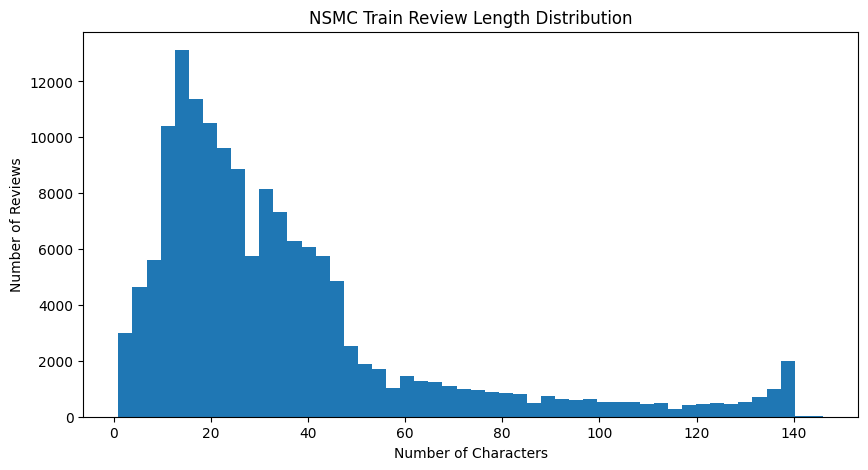

In [16]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 5))

plt.hist(
    train_lengths,
    bins=50
)

plt.title("NSMC Train Review Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Reviews")
plt.show()

In [17]:
# 테스트 힌트를 주는 훈련데이터가 있는지~ 학습 품질검사

In [18]:
if len(overlap_documents) > 0:
    overlap_examples = list(overlap_documents)[:10]

    display(
        train_df[
            train_df["document"].isin(overlap_examples)
        ].sort_values("document")
    )

    display(
        test_df[
            test_df["document"].isin(overlap_examples)
        ].sort_values("document")
   )

NameError: name 'overlap_documents' is not defined

### 코퍼스 분석 결과

NSMC 원본 데이터의 구조와 품질을 확인했다.

- Train: 150,000개
- Test: 50,000개
- Train document 결측치: 5개
- Test document 결측치: 3개
- Train 중복 리뷰: 3,817개
- Test 중복 리뷰: 842개
- Train에서 동일한 리뷰가 서로 다른 label을 갖는 경우: 157개

Train label 분포는 부정 75,173개, 긍정 74,827개로
약 50:50의 균형을 이루고 있다.
따라서 본 프로젝트에서는 Accuracy를 주요 평가 지표로 사용한다.

리뷰 길이는 문자 기준 평균 약 35자, 중앙값 27자이며
95%가 107자 이하, 99%가 139자 이하로 확인되었다.

다만 실제 모델 입력 길이는 SentencePiece 토큰화 이후의
token sequence 길이에 따라 달라지므로,
padding 길이는 tokenizer 구축 이후 다시 분석하여 결정한다.

전처리 과정에서는 감성 정보를 포함할 수 있는
'ㅋㅋ', 'ㅠㅠ', 문장부호 등을 임의로 제거하지 않고,
결측치·공백·중복·상충 label과 같은 데이터 품질 문제를
중심으로 최소한의 정제를 수행한다.

## NSMC 데이터 전처리

코퍼스 분석 결과 결측치, 중복 리뷰, label conflict,
Train/Test 간 동일 리뷰가 확인되었다. 꽤 된다.

감성 표현을 훼손하지 않기 위해 한글 이외의 문자나 문장부호를
일괄 제거하지 않고 다음 데이터 품질 문제만 정제한다.

1. 결측치 및 빈 문자열 제거
2. 불필요한 연속 공백 정규화
3. 동일 문장에 서로 다른 label이 존재하는 conflict 제거
4. 동일 문장의 중복 제거
5. 평가 데이터 누수를 방지하기 위해 Train/Test 중복 문장을 Train에서 제거

정제된 Train 데이터만 SentencePiece 학습에 사용해서 더 나은 학습결과를 기대한다.

In [19]:
import re


def normalize_text(text):
    """
    감성 표현은 유지하면서 whitespace만 최소 정규화한다.
    """
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text

In [20]:
#학습, 테스트 데이터에 둘 다 적용할 함수

def clean_nsmc(df, name="dataset"):
    clean_df = df.copy()

    original_count = len(clean_df)

    # 1. document 결측치 제거
    clean_df = clean_df.dropna(subset=["document"]).copy()
    after_dropna = len(clean_df)

    # 2. 최소 텍스트 정규화
    clean_df["document"] = clean_df["document"].map(normalize_text)

    # 3. 빈 문자열 제거
    clean_df = clean_df[
        clean_df["document"].str.len() > 0
    ].copy()
    after_empty = len(clean_df)

    # 4. 동일 document에 서로 다른 label이 붙은 경우 찾기
    label_counts = (
        clean_df.groupby("document")["label"]
        .nunique()
    )

    conflict_documents = set(
        label_counts[label_counts > 1].index
    )

    # conflict에 해당하는 document는 전체 제거
    clean_df = clean_df[
        ~clean_df["document"].isin(conflict_documents)
    ].copy()
    after_conflict = len(clean_df)

    # 5. 동일 document 중복 제거
    clean_df = clean_df.drop_duplicates(
        subset=["document"],
        keep="first"
    ).copy()
    after_duplicates = len(clean_df)

    clean_df = clean_df.reset_index(drop=True)

    print(f"=== {name} cleaning ===")
    print(f"Original             : {original_count:,}")
    print(f"After missing removal: {after_dropna:,}")
    print(f"After empty removal  : {after_empty:,}")
    print(f"Conflict documents   : {len(conflict_documents):,}")
    print(f"After conflict removal: {after_conflict:,}")
    print(f"After duplicate removal: {after_duplicates:,}")

    return clean_df

In [21]:
train_clean = clean_nsmc(
    train_df,
    name="TRAIN"
)

print()

test_clean = clean_nsmc(
    test_df,
    name="TEST"
)

=== TRAIN cleaning ===
Original             : 150,000
After missing removal: 149,995
After empty removal  : 149,995
Conflict documents   : 157
After conflict removal: 148,544
After duplicate removal: 146,025

=== TEST cleaning ===
Original             : 50,000
After missing removal: 49,997
After empty removal  : 49,997
Conflict documents   : 47
After conflict removal: 49,691
After duplicate removal: 49,110


In [22]:
#잘 정제됐는지 확인해보기~
train_documents = set(train_clean["document"])
test_documents = set(test_clean["document"])

overlap_after_cleaning = (
    train_documents & test_documents
)

print(
    "Train/Test overlap before removal:",
    len(overlap_after_cleaning)
)

Train/Test overlap before removal: 694


In [23]:
train_clean = train_clean[
    ~train_clean["document"].isin(overlap_after_cleaning)
].reset_index(drop=True)

print("Train size after leakage removal:",
      len(train_clean))

print("Test size:",
      len(test_clean))

Train size after leakage removal: 145331
Test size: 49110


In [24]:
print("=== CLEAN DATA SUMMARY ===")

print("Train shape:", train_clean.shape)
print("Test shape :", test_clean.shape)

print()

print(
    "Train missing:",
    train_clean["document"].isna().sum()
)

print(
    "Test missing :",
    test_clean["document"].isna().sum()
)

print()

print(
    "Train duplicate:",
    train_clean["document"].duplicated().sum()
)

print(
    "Test duplicate :",
    test_clean["document"].duplicated().sum()
)

print()

final_overlap = (
    set(train_clean["document"])
    & set(test_clean["document"])
)

print(
    "Train/Test overlap:",
    len(final_overlap)
)

print()

print("=== Train label ratio ===")
print(
    train_clean["label"]
    .value_counts(normalize=True)
    .sort_index()
)

print()

print("=== Test label ratio ===")
print(
    test_clean["label"]
    .value_counts(normalize=True)
    .sort_index()
)

=== CLEAN DATA SUMMARY ===
Train shape: (145331, 3)
Test shape : (49110, 3)

Train missing: 0
Test missing : 0

Train duplicate: 0
Test duplicate : 0

Train/Test overlap: 0

=== Train label ratio ===
label
0    0.501655
1    0.498345
Name: proportion, dtype: float64

=== Test label ratio ===
label
0    0.497312
1    0.502688
Name: proportion, dtype: float64


### 주의사항!
이번 방식에서는 원본 50,000개짜리 NSMC test set에서 conflict와 duplicate를 일부 제거하기 때문에 이후 말하는 test accuracy는 엄밀히 말하면:
정제된 NSMC test set에서의 accuracy 입니다~~~

## SentencePiece 학습용 코퍼스 생성

전처리가 완료된 NSMC Train 데이터의 `document` 컬럼만 사용하여
SentencePiece 학습용 텍스트 코퍼스를 생성한다.

- 한 리뷰를 한 줄에 저장한다.
- Test 데이터는 SentencePiece 학습에 사용하지 않는다.
- 첫 번째 baseline은 `Unigram`, `vocab_size=8000`으로 설정한다.

SentencePiece는 raw sentence에서 직접 subword vocabulary를 학습하므로
형태소 분석이나 공백 단위 사전 토큰화를 별도로 수행하지 않는다.

In [25]:
# corpus 파일 저장
SPM_CORPUS_PATH = DATA_DIR / "nsmc_spm_train.txt"

with open(SPM_CORPUS_PATH, "w", encoding="utf-8") as f:
    for text in train_clean["document"]:
        f.write(text + "\n")

print("Corpus path :", SPM_CORPUS_PATH)
print("Sentence count:", len(train_clean))

Corpus path : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/nsmc_spm_train.txt
Sentence count: 145331


In [26]:
# 파일 확인
print("File exists:", SPM_CORPUS_PATH.exists())

with open(SPM_CORPUS_PATH, "r", encoding="utf-8") as f:
    for _ in range(5):
        print(f.readline().rstrip())

File exists: True
아 더빙.. 진짜 짜증나네요 목소리
흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나
너무재밓었다그래서보는것을추천한다
교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정
사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 던스트가 너무나도 이뻐보였다


## 첫 번째 SentencePiece 모델 학습

In [30]:
#Unigram 8k 모델 학습을 해보자.

SPM_MODEL_PREFIX = SPM_DIR / "nsmc_unigram_8000"

spm.SentencePieceTrainer.train(
    input=str(SPM_CORPUS_PATH),
    model_prefix=str(SPM_MODEL_PREFIX),
    vocab_size=8000,
    model_type="unigram",
    character_coverage=0.9995,

    # 이후 PyTorch padding과 명확히 맞추기 위해 직접 지정
    pad_id=0,
    unk_id=1,

    # 이번 감성분류에서는 문장 시작/끝 토큰을 사용하지 않음
    bos_id=-1,
    eos_id=-1,
)

True

In [31]:
SPM_MODEL_PATH = Path(str(SPM_MODEL_PREFIX) + ".model")
SPM_VOCAB_PATH = Path(str(SPM_MODEL_PREFIX) + ".vocab")

print("Model exists:", SPM_MODEL_PATH.exists())
print("Vocab exists:", SPM_VOCAB_PATH.exists())

print("Model path:", SPM_MODEL_PATH)
print("Vocab path:", SPM_VOCAB_PATH)

Model exists: True
Vocab exists: True
Model path: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/sentencepiece/nsmc_unigram_8000.model
Vocab path: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/sentencepiece/nsmc_unigram_8000.vocab


In [32]:
SPM_MODEL_PATH = (
    SPM_DIR / "nsmc_unigram_8000.model"
)

sp = spm.SentencePieceProcessor(
    model_file=str(SPM_MODEL_PATH)
)

print(sp.get_piece_size())

8000


In [33]:
#토크나이저 불러오기. 학습된 모델 내부 설정을 확인하고자 함
sp = spm.SentencePieceProcessor(
    model_file=str(SPM_MODEL_PATH)
)

print("Vocabulary size:", sp.get_piece_size())

print("PAD ID:", sp.pad_id())
print("UNK ID:", sp.unk_id())
print("BOS ID:", sp.bos_id())
print("EOS ID:", sp.eos_id())

Vocabulary size: 8000
PAD ID: 0
UNK ID: 1
BOS ID: -1
EOS ID: -1


In [34]:
# 드디어 한국어 문장 토큰화 확인
sample_texts = [
    "내가하는말이무슨말인지알쥐?모르뉘?",
    "정말 재미있는 영화였습니다!",
    "진짜 최악이네요ㅋㅋ 다시는 안 볼 듯",
]

for text in sample_texts:
    pieces = sp.encode(text, out_type=str)
    ids = sp.encode(text, out_type=int)
    decoded = sp.decode(ids)

    print("=" * 60)
    print("원문   :", text)
    print("Pieces :", pieces)
    print("IDs    :", ids)
    print("복원   :", decoded)

원문   : 내가하는말이무슨말인지알쥐?모르뉘?
Pieces : ['▁내가', '하는', '말이', '무슨', '말', '인지', '알', '쥐', '?', '모르', '뉘', '?']
IDs    : [129, 53, 1625, 2046, 216, 313, 771, 3819, 19, 1925, 7210, 19]
복원   : 내가하는말이무슨말인지알쥐?모르뉘?
원문   : 정말 재미있는 영화였습니다!
Pieces : ['▁정말', '▁재미있는', '▁영화였습니다', '!']
IDs    : [26, 1239, 2221, 25]
복원   : 정말 재미있는 영화였습니다!
원문   : 진짜 최악이네요ㅋㅋ 다시는 안 볼 듯
Pieces : ['▁진짜', '▁최악', '이네요', 'ᄏᄏ', '▁다시', '는', '▁안', '▁볼', '▁듯']
IDs    : [31, 420, 942, 137, 144, 11, 44, 202, 517]
복원   : 진짜 최악이네요ᄏᄏ 다시는 안 볼 듯


## SentencePiece 기반 `sp_tokenize()` 구현

학습된 SentencePiece 모델을 이용하여 문장을 다음 과정으로 변환한다.

문장
→ Subword Tokenization
→ Token ID
→ PyTorch Tensor
→ Padding

또한 SentencePiece가 생성한 `.vocab` 파일을 읽어
`word_index`와 `index_word` 사전을 생성한다.

이 단계의 결과인 Token ID는 아직 의미 벡터(Embedding)가 아니며,
이후 감성분류 모델의 Embedding Layer에 입력될 정수 인덱스이다.

In [35]:
def sp_tokenize(s, corpus, vocab_path=SPM_VOCAB_PATH):
    """
    SentencePiece로 문장을 Token ID sequence로 변환하고
    동일 길이가 되도록 padding한다.

    Parameters
    ----------
    s : sentencepiece.SentencePieceProcessor
        학습된 SentencePiece tokenizer

    corpus : iterable of str
        토큰화할 원문 문장들

    vocab_path : Path or str
        SentencePiece가 생성한 .vocab 파일 경로

    Returns
    -------
    tensor : torch.LongTensor
        shape = [batch_size, max_sequence_length]

    word_index : dict
        {token: id}

    index_word : dict
        {id: token}
    """

    sequences = []

    # 1. 문장 → Token IDs → PyTorch Tensor
    for sentence in corpus:
        token_ids = s.encode(sentence, out_type=int)

        sequences.append(
            torch.tensor(token_ids, dtype=torch.long)
        )

    # 2. 문장 길이를 맞추기 위해 Padding
    tensor = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=s.pad_id()
    )
      # PAD를 0으로 설정했지만,
      # 코드에 그냥 0이라고 박아놓기보다
      # 현재 SentencePiece 모델에게 PAD ID가 몇 번인지 물어보는 방식

    # 3. SentencePiece vocab 읽기
    word_index = {}
    index_word = {}

    with open(vocab_path, "r", encoding="utf-8") as f:
        for idx, line in enumerate(f):
            piece = line.rstrip("\n").split("\t")[0]

            word_index[piece] = idx
            index_word[idx] = piece

    return tensor, word_index, index_word

In [36]:
sample_corpus = train_clean["document"].iloc[:5].tolist()

sample_tensor, word_index, index_word = sp_tokenize(
    sp,
    sample_corpus
)

print("Tensor shape:", sample_tensor.shape)
print()
print(sample_tensor)

Tensor shape: torch.Size([5, 33])

tensor([[  63,  883,    5,   31, 2179,   66, 1840,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0],
        [1802,    7, 4974,  159, 1425,   30,  270,   64,  173,  412,  368, 1338,
         6834,  837,  410,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0],
        [  23,  385, 7764,  344, 3925,   96, 6069, 2076,  330,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0],
        [1826,    9,  192,  234, 6638,    2,    5, 4377, 1309,  120,    5,  683,
          278,   99,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0],
        [2233, 2401, 2059,  166,    8,    2, 1445,  318, 2248

In [37]:
# 흠.. 실제 피스와 ID와 패딩 관계를 좀 더 확인해보겠습니다
for i, text in enumerate(sample_corpus[:3]):
    pieces = sp.encode(text, out_type=str)
    ids = sp.encode(text, out_type=int)

    print("=" * 70)
    print("원문     :", text)
    print("Pieces   :", pieces)
    print("IDs      :", ids)
    print("Padded   :", sample_tensor[i].tolist())

원문     : 아 더빙.. 진짜 짜증나네요 목소리
Pieces   : ['▁아', '▁더빙', '..', '▁진짜', '▁짜증나', '네요', '▁목소리']
IDs      : [63, 883, 5, 31, 2179, 66, 1840]
Padded   : [63, 883, 5, 31, 2179, 66, 1840, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
원문     : 흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나
Pieces   : ['▁흠', '...', '포스터', '보고', '▁초딩', '영화', '줄', '....', '오', '버', '연기', '조차', '▁가볍지', '▁않', '구나']
IDs      : [1802, 7, 4974, 159, 1425, 30, 270, 64, 173, 412, 368, 1338, 6834, 837, 410]
Padded   : [1802, 7, 4974, 159, 1425, 30, 270, 64, 173, 412, 368, 1338, 6834, 837, 410, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
원문     : 너무재밓었다그래서보는것을추천한다
Pieces   : ['▁너무', '재', '밓', '었다', '그래서', '보', '는것을', '추천', '한다']
IDs      : [23, 385, 7764, 344, 3925, 96, 6069, 2076, 330]
Padded   : [23, 385, 7764, 344, 3925, 96, 6069, 2076, 330, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [38]:
# Vocab와 SP 모델이 같은 아이디 쓰는 지 검증
print("word_index size:", len(word_index))
print("index_word size:", len(index_word))

print()
print("ID 0:", index_word[0])
print("ID 1:", index_word[1])

print()
print("'▁정말' ID from dictionary:",
      word_index.get("▁정말"))

print("'▁정말' ID from SentencePiece:",
      sp.piece_to_id("▁정말"))

word_index size: 8000
index_word size: 8000

ID 0: <pad>
ID 1: <unk>

'▁정말' ID from dictionary: 26
'▁정말' ID from SentencePiece: 26


In [39]:
vocab_matches = all(
    index_word[idx] == sp.id_to_piece(idx)
    for idx in range(sp.get_piece_size())
)

print("Vocab ID mapping matches:", vocab_matches)

Vocab ID mapping matches: True


## SentencePiece 토큰 길이 분석

원문 문자 길이와 실제 모델이 입력받는 Token Sequence 길이는 서로 다르다.

따라서 학습된 SentencePiece Tokenizer를 Train 데이터에 적용하여
각 리뷰의 token 수를 측정하고, 이를 바탕으로 모델 입력의
최대 길이(`max_len`)를 결정한다.

왜냐!!!!!
너무 짧은 `max_len`은 리뷰의 정보를 많이 잘라내고,
너무 긴 `max_len`은 Padding 비율과 연산량을 증가시킨다.

In [40]:
#전체 학습데이터 길이 측정하기
train_token_lengths = train_clean["document"].map(
    lambda text: len(sp.encode(text, out_type=int))
)

print(train_token_lengths.describe())

print()
print(
    "90 percentile:",
    np.percentile(train_token_lengths, 90)
)

print(
    "95 percentile:",
    np.percentile(train_token_lengths, 95)
)

print(
    "99 percentile:",
    np.percentile(train_token_lengths, 99)
)

print(
    "Max token length:",
    train_token_lengths.max()
)

count    145331.000000
mean         17.403906
std          14.788450
min           1.000000
25%           8.000000
50%          13.000000
75%          21.000000
max         134.000000
Name: document, dtype: float64

90 percentile: 36.0
95 percentile: 52.0
99 percentile: 72.0
Max token length: 134


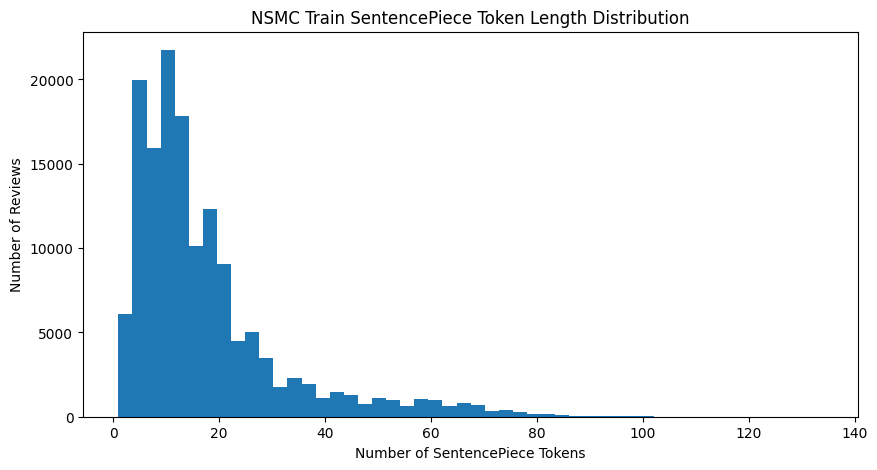

In [41]:
plt.figure(figsize=(10, 5))

plt.hist(
    train_token_lengths,
    bins=50
)

plt.title("NSMC Train SentencePiece Token Length Distribution")
plt.xlabel("Number of SentencePiece Tokens")
plt.ylabel("Number of Reviews")

plt.show()

In [42]:
#후보별 보존율 확인. 뭘로 정하느냐에 따라 학습 효율과 원본 전달력(?)이 최적화될테니
max_len_candidates = [40, 50, 60, 80, 100]

for max_len in max_len_candidates:
    coverage = (
        train_token_lengths <= max_len
    ).mean()

    print(
        f"max_len={max_len:3d} "
        f"| coverage={coverage:.4%}"
    )

max_len= 40 | coverage=91.7017%
max_len= 50 | coverage=94.6343%
max_len= 60 | coverage=96.9669%
max_len= 80 | coverage=99.6773%
max_len=100 | coverage=99.9745%


In [43]:
#UNK 확인
UNK_ID = sp.unk_id()

total_tokens = 0
unk_tokens = 0
sentences_with_unk = 0

for text in train_clean["document"]:
    ids = sp.encode(text, out_type=int)

    total_tokens += len(ids)

    current_unk = ids.count(UNK_ID)
    unk_tokens += current_unk

    if current_unk > 0:
        sentences_with_unk += 1

print("Total tokens:", total_tokens)
print("UNK tokens  :", unk_tokens)

print(
    "UNK token rate:",
    unk_tokens / total_tokens
)

print(
    "Sentences containing UNK:",
    sentences_with_unk
)

print(
    "Sentence UNK rate:",
    sentences_with_unk / len(train_clean)
)

Total tokens: 2529327
UNK tokens  : 2377
UNK token rate: 0.0009397756794593977
Sentences containing UNK: 2134
Sentence UNK rate: 0.014683721986362166


### Token Length 및 UNK 분석

SentencePiece 적용 후 Train 데이터의 token sequence 길이를 분석했다.

- `max_len=40`: 91.70%
- `max_len=50`: 94.63%
- `max_len=60`: 96.97%
- `max_len=80`: 99.68%
- `max_len=100`: 99.97%

`max_len=80`에서 약 99.7%의 리뷰를 자르지 않고 보존할 수 있으므로,
정보 보존과 연산 효율의 균형을 고려하여 본 실험의 최대 입력 길이를
80으로 결정했다.

또한 전체 2,529,327개의 SentencePiece token 중 `<unk>` token은
2,377개로 약 0.094%였으며, `<unk>`가 하나 이상 포함된 문장은
전체 Train 데이터의 약 1.47%였다.

따라서 현재의 Unigram / vocab_size=8000 설정은 NSMC 코퍼스의
대부분을 subword 단위로 표현할 수 있는 것으로 판단했다.

In [44]:
# 실행셀 만들어두기
SEED = 21
VOCAB_SIZE = 8000
MAX_LEN = 80

PAD_ID = sp.pad_id()
UNK_ID = sp.unk_id()

print("SEED       :", SEED)
print("VOCAB_SIZE :", VOCAB_SIZE)
print("MAX_LEN    :", MAX_LEN)
print("PAD_ID     :", PAD_ID)
print("UNK_ID     :", UNK_ID)

SEED       : 21
VOCAB_SIZE : 8000
MAX_LEN    : 80
PAD_ID     : 0
UNK_ID     : 1


## Train / Validation 데이터 분리

전처리가 완료된 `train_clean` 데이터를 실제 모델 학습용 Train과
학습 과정의 일반화 성능을 확인하기 위한 Validation으로 분리한다.

- Train: 90%
- Validation: 10%
- Test: 기존 `test_clean`을 그대로 유지

감성 label(0/1)의 비율이 Train과 Validation에서 비슷하게 유지되도록
label별로 분리한다.

재현성을 위해 random seed는 21로 고정한다.

In [45]:
import random

SEED = 21

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("SEED:", SEED)

SEED: 21


In [46]:
# 학습/ 검증 분리
VAL_RATIO = 0.10

# label 0 / 1 각각에서 10%씩 Validation으로 추출
val_df = (
    train_clean
    .groupby("label", group_keys=False)
    .sample(frac=VAL_RATIO, random_state=SEED)
)

# Validation으로 뽑힌 행을 제외한 나머지가 실제 Train
model_train_df = train_clean.drop(index=val_df.index)

# index 정리
model_train_df = model_train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Model Train shape:", model_train_df.shape)
print("Validation shape :", val_df.shape)
print("Test shape       :", test_clean.shape)

Model Train shape: (130798, 3)
Validation shape : (14533, 3)
Test shape       : (49110, 3)


In [47]:
# 분할 결과 검증. 레이블 비율이나, 겹치는 거 없는지 ..
print("=== Model Train label ratio ===")
print(
    model_train_df["label"]
    .value_counts(normalize=True)
    .sort_index()
)

print()

print("=== Validation label ratio ===")
print(
    val_df["label"]
    .value_counts(normalize=True)
    .sort_index()
)

print()

train_val_overlap = (
    set(model_train_df["document"])
    & set(val_df["document"])
)

print(
    "Train/Validation overlap:",
    len(train_val_overlap)
)

=== Model Train label ratio ===
label
0    0.501651
1    0.498349
Name: proportion, dtype: float64

=== Validation label ratio ===
label
0    0.501686
1    0.498314
Name: proportion, dtype: float64

Train/Validation overlap: 0


In [48]:
# 고정 길이 인코딩 함수 적용하기!
MAX_LEN = 80
PAD_ID = sp.pad_id()


def encode_fixed_length(text, tokenizer, max_len=MAX_LEN):
    """
    문장을 SentencePiece Token ID로 변환한 뒤
    max_len 길이로 Padding 또는 Truncation한다.
    """

    # 1. 문장 → Token IDs
    token_ids = tokenizer.encode(
        text,
        out_type=int
    )

    # 2. 실제 사용할 길이
    valid_length = min(
        len(token_ids),
        max_len
    )

    # 3. max_len보다 길면 자르기
    token_ids = token_ids[:max_len]

    # 4. 전체를 PAD로 채운 Tensor 생성
    input_ids = torch.full(
        (max_len,),
        fill_value=tokenizer.pad_id(),
        dtype=torch.long
    )

    # 5. 실제 token이 있는 앞부분만 채움
    if valid_length > 0:
        input_ids[:valid_length] = torch.tensor(
            token_ids,
            dtype=torch.long
        )

    return input_ids, valid_length

센스 있게 vaild length 라는 것도 적용해보았습니다... 하 하 하

In [49]:
# 맛보기
sample_text = "정말 재미있는 영화였습니다!"

sample_ids, sample_length = encode_fixed_length(
    sample_text,
    sp
)

print("Original text :", sample_text)
print("Tensor shape  :", sample_ids.shape)
print("Valid length  :", sample_length)
print("Input IDs     :", sample_ids)

Original text : 정말 재미있는 영화였습니다!
Tensor shape  : torch.Size([80])
Valid length  : 4
Input IDs     : tensor([  26, 1239, 2221,   25,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])


In [50]:
print(
    "Non-PAD count:",
    (sample_ids != PAD_ID).sum().item()
)

print(
    "Decoded:",
    sp.decode(
        sample_ids[:sample_length].tolist()
    )
)

Non-PAD count: 4
Decoded: 정말 재미있는 영화였습니다!


## PyTorch Dataset 구성

각 영화 리뷰를 하나의 학습 sample로 구성한다.

하나의 sample은 다음 세 값을 반환한다.

- `input_ids`: 길이 80의 SentencePiece Token ID Tensor
- `length`: Padding을 제외한 실제 Token 길이
- `label`: 감성 정답 (0=부정, 1=긍정)

이 Dataset을 이후 DataLoader가 여러 sample씩 묶어 Batch로 전달한다.

In [51]:
from torch.utils.data import Dataset, DataLoader


class NSMCSentencePieceDataset(Dataset):

    def __init__(
        self,
        dataframe,
        tokenizer,
        max_len=MAX_LEN
    ):
        self.texts = dataframe["document"].tolist()
        self.labels = dataframe["label"].tolist()

        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        text = self.texts[idx]
        label = self.labels[idx]

        input_ids, valid_length = encode_fixed_length(
            text,
            self.tokenizer,
            self.max_len
        )

        return {
            "input_ids": input_ids,

            "length": torch.tensor(
                valid_length,
                dtype=torch.long
            ),

            "label": torch.tensor(
                label,
                dtype=torch.long
            ),
        }

### 하나의 샘플은 이렇게 생겼어요:


```
{
    input_ids : tensor([..., 80개 ...]),
    length    : tensor(실제길이),
    label     : tensor(0 또는 1)
}
```



In [52]:
# 데이터셋 생성
train_dataset = NSMCSentencePieceDataset(
    model_train_df,
    sp,
    MAX_LEN
)

val_dataset = NSMCSentencePieceDataset(
    val_df,
    sp,
    MAX_LEN
)

print(
    "Train Dataset size:",
    len(train_dataset)
)

print(
    "Validation Dataset size:",
    len(val_dataset)
)

Train Dataset size: 130798
Validation Dataset size: 14533


In [53]:
# 맛보기
sample = train_dataset[0]

print(
    "input_ids shape:",
    sample["input_ids"].shape
)

print(
    "length:",
    sample["length"]
)

print(
    "label:",
    sample["label"]
)

print()
print(
    "Decoded:",
    sp.decode(
        sample["input_ids"][
            :sample["length"].item()
        ].tolist()
    )
)

input_ids shape: torch.Size([80])
length: tensor(7)
label: tensor(0)

Decoded: 아 더빙.. 진짜 짜증나네요 목소리


In [54]:
# 데이터로더 생성~
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

Train batches: 2044
Validation batches: 228


In [55]:
# 한 배치의 텐서 모양 확인
batch = next(iter(train_loader))

input_ids = batch["input_ids"]
lengths = batch["length"]
labels = batch["label"]

print(
    "input_ids shape:",
    input_ids.shape
)

print(
    "lengths shape  :",
    lengths.shape
)

print(
    "labels shape   :",
    labels.shape
)

input_ids shape: torch.Size([64, 80])
lengths shape  : torch.Size([64])
labels shape   : torch.Size([64])


### 이 말인 즉슨...


```
input_ids.shape
[64, 80]
 │   │
 │   └─ 한 리뷰당 최대 80 tokens
 │
 └──── 한 번에 64개 리뷰
```


```
Batch 1

리뷰 1  [80 token IDs]
리뷰 2  [80 token IDs]
리뷰 3  [80 token IDs]
...
리뷰 64 [80 token IDs]

      ↓

Tensor
[64 × 80]
```

이게 다음 단계 임베딩 레이어 입력값이 되는것!


In [56]:
# 배치 한문장 자세히 보기
sample_idx = 0

first_ids = input_ids[sample_idx]
first_length = lengths[sample_idx].item()
first_label = labels[sample_idx].item()

print(
    "Tensor shape:",
    first_ids.shape
)

print(
    "Valid length:",
    first_length
)

print(
    "Label:",
    first_label
)

print()

print(
    "Token IDs:",
    first_ids[:first_length].tolist()
)

print()

print(
    "Pieces:",
    [
        sp.id_to_piece(token_id)
        for token_id
        in first_ids[:first_length].tolist()
    ]
)

print()

print(
    "Decoded:",
    sp.decode(
        first_ids[:first_length].tolist()
    )
)

Tensor shape: torch.Size([80])
Valid length: 26
Label: 1

Token IDs: [4458, 731, 5755, 2304, 107, 66, 3, 4938, 3846, 535, 2321, 353, 4368, 4838, 38, 7183, 13, 2, 2393, 11, 1245, 181, 3068, 219, 662, 3]

Pieces: ['▁최근에', '▁봤던', '▁예술영화', '▁중에', '▁최고', '네요', '.', '▁불편한', '▁감정을', '▁건', '드리', '면서', '▁여러가지', '▁철학적', '인', '▁질문', '을', '▁', '던지', '는', '▁생각을', '▁많이', '▁하게', '▁하는', '▁영화입니다', '.']

Decoded: 최근에 봤던 예술영화 중에 최고네요. 불편한 감정을 건드리면서 여러가지 철학적인 질문을 던지는 생각을 많이 하게 하는 영화입니다.


## Embedding Layer 이해하기

SentencePiece가 반환한 Token ID는 vocabulary에서 각 token의 위치를
나타내는 정수 인덱스일 뿐, 숫자 자체에는 의미적 관계가 없다.

따라서 `nn.Embedding`을 사용하여 각 Token ID를 학습 가능한
Dense Vector로 변환한다.

Baseline 설정:

- Vocabulary size: 8,000
- Embedding dimension: 128
- Padding ID: 0

Embedding Layer의 가중치는 이후 감성분류 Loss의 역전파를 통해
분류 작업에 적합한 방향으로 함께 학습된다고 한다...

입력 Tensor의 변화:

`[batch, sequence]`
→ Embedding
→ `[batch, sequence, embedding_dim]`

In [57]:
# 임베딩 레이어 생성
import torch.nn as nn

EMBEDDING_DIM = 128

embedding = nn.Embedding(
    num_embeddings=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    padding_idx=PAD_ID
)

print(embedding)

Embedding(8000, 128, padding_idx=0)


In [58]:
embedded = embedding(input_ids)

print("Input IDs shape :", input_ids.shape)
print("Embedded shape  :", embedded.shape)

Input IDs shape : torch.Size([64, 80])
Embedded shape  : torch.Size([64, 80, 128])


In [59]:
# 맛보기
sample_token_id = input_ids[0, 0].item()

print("Token ID :", sample_token_id)
print("Piece    :", sp.id_to_piece(sample_token_id))

sample_vector = embedded[0, 0]

print()
print("Embedding vector shape:", sample_vector.shape)
print("Embedding vector:")
print(sample_vector)

Token ID : 4458
Piece    : ▁최근에

Embedding vector shape: torch.Size([128])
Embedding vector:
tensor([-3.2670e-02,  2.0073e+00,  2.2611e-02,  9.0725e-01,  1.3650e+00,
         7.2569e-01, -1.2237e+00, -2.3344e-01,  1.8983e-01, -4.1349e-01,
        -9.1693e-01,  7.0174e-01,  2.2116e+00,  9.4555e-01,  8.3774e-01,
        -7.1651e-01, -1.1444e+00,  3.1833e-01, -1.6382e-01, -5.6942e-01,
        -9.7355e-01, -1.4571e+00,  1.7746e+00,  9.2416e-01, -1.7861e+00,
         1.1113e+00,  2.9464e-01, -1.6572e+00,  7.3014e-01, -1.1261e+00,
        -9.3267e-01, -6.2242e-01, -6.9386e-01,  3.6337e-01,  5.8691e-01,
         8.5378e-01,  3.3356e-01, -1.0303e+00,  3.7163e-02, -1.9208e+00,
         3.5937e-01, -5.3913e-01,  4.5099e-02, -9.2767e-01, -1.2163e+00,
         1.1456e+00, -5.3363e-01, -3.6616e-01, -9.9079e-01, -5.2314e-01,
         1.3784e+00, -1.2109e+00, -6.3622e-01, -6.7821e-01, -4.5926e-01,
        -1.7183e+00, -1.0774e+00, -1.2481e-01, -4.9555e-01,  1.6278e+00,
         1.1081e-01, -3.3474e-0

In [60]:
print("PAD piece:", sp.id_to_piece(PAD_ID))
print("PAD ID   :", PAD_ID)

print()
print("PAD embedding:")
print(embedding.weight[PAD_ID])

PAD piece: <pad>
PAD ID   : 0

PAD embedding:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.], grad_fn=<SelectBackward0>)


## 주의사항!
지금 단계에서 128을 너무 의미 있게 해석할 필요 없다는 점!

EMBEDDING_DIM=128은 baseline 하이퍼파라미터라고 한다.

128개의 각 축이 사람이 정해둔:

1번 축 = 긍정성
2번 축 = 영화 장르
3번 축 = 감정 정도
...

인 것도 아니거니와~

분산표현에서 배웠듯이 의미는 128차원 전체에 분산되어 학습됨.

그리고 지금은 아직 학습 전이므로 어찌보면

```
현재 embedding
= 학습 가능한 자리만 마련한 상태

앞으로
= 감성분류 Loss에 따라 실제 값들이 조정됨
```


이라고 이해하는 게 가장 정확함

## SentencePiece + LSTM 감성분류 모델


SentencePiece Tokenizer가 생성한 Token ID sequence를
Embedding Layer와 LSTM에 연결하여 영화 리뷰의 감성을 분류한다.

모델 구조:

`Token IDs`
→ `Embedding`
→ `LSTM`
→ `Dropout`
→ `Linear`
→ `Negative / Positive`

Padding된 영역이 LSTM의 문장 표현에 영향을 주지 않도록
`각 리뷰의 실제 token 길이`를 이용한다.

이번 프로젝트의 핵심 비교 대상은 Tokenizer이므로,
분류 모델은 단순한 단방향 LSTM 구조로 고정한다.

In [61]:
from torch.nn.utils.rnn import pack_padded_sequence

In [62]:
# 감성분류모델 정의
class SentimentLSTM(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        num_classes,
        pad_id,
        dropout=0.3
    ):
        super().__init__()

        # Token ID → Dense Vector
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_id
        )

        # Sequence 정보 처리
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)

        # 문장 표현 → 부정/긍정 점수
        self.fc = nn.Linear(
            hidden_dim,
            num_classes
        )

    def forward(self, input_ids, lengths):

        # [batch, seq]
        # → [batch, seq, embedding_dim]
        embedded = self.embedding(input_ids)

        # 실제 문장 길이까지만 LSTM이 처리
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        # h_n: 마지막 hidden state
        _, (h_n, _) = self.lstm(packed)

        # 단방향 1-layer LSTM이므로 마지막 hidden state 사용
        last_hidden = h_n[-1]

        # 과적합 완화
        last_hidden = self.dropout(last_hidden)

        # [batch, hidden_dim]
        # → [batch, 2]
        logits = self.fc(last_hidden)

        return logits

In [63]:
# 모델 생성
HIDDEN_DIM = 128
NUM_CLASSES = 2
DROPOUT = 0.3

model = SentimentLSTM(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    pad_id=PAD_ID,
    dropout=DROPOUT
)

print(model)

SentimentLSTM(
  (embedding): Embedding(8000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


In [64]:
# 한 배치만 넣어보기
logits = model(
    input_ids,
    lengths
)

print("Input shape :", input_ids.shape)
print("Logits shape:", logits.shape)

print()
print("First 5 logits:")
print(logits[:5])

Input shape : torch.Size([64, 80])
Logits shape: torch.Size([64, 2])

First 5 logits:
tensor([[-0.0239, -0.0569],
        [-0.0208, -0.0254],
        [-0.1734, -0.1458],
        [-0.2415, -0.1058],
        [-0.1242, -0.0930]], grad_fn=<SliceBackward0>)


In [65]:
# 예측 형태 확인
predictions = logits.argmax(dim=1)

print("Predictions shape:", predictions.shape)

print("First 10 predictions:")
print(predictions[:10])

print()

print("First 10 labels:")
print(labels[:10])

Predictions shape: torch.Size([64])
First 10 predictions:
tensor([0, 0, 1, 1, 1, 1, 1, 1, 1, 1])

First 10 labels:
tensor([1, 1, 0, 1, 0, 1, 0, 0, 0, 1])


In [66]:
# 이진분류이므로 크로스엔트로피 로스 짜기
criterion = nn.CrossEntropyLoss()

loss = criterion(
    logits,
    labels
)

print("Loss:", loss.item())

Loss: 0.6998963356018066


## Optimizer와 Backpropagation 확인

모델의 Forward Pass와 Loss 계산이 정상적으로 동작하는 것을 확인하였다.

다음으로 Optimizer와 Backpropagation을 연결하여
Loss를 기준으로 모델의 가중치가 실제로 업데이트되는지 확인한다.

전체 학습에 앞서 한 Batch만 사용하여
`Forward → Loss → Backward → Weight Update` 흐름을 검증한다.

In [67]:
# 옵티마이저 생성
import torch.optim as optim

LEARNING_RATE = 1e-3

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [68]:
CHECK_TOKEN_ID = sp.piece_to_id("▁최근에")

before_update = (
    model.embedding.weight[CHECK_TOKEN_ID]
    .detach()
    .clone()
)

print("Token:", sp.id_to_piece(CHECK_TOKEN_ID))
print("Before update:")
print(before_update[:10])

Token: ▁최근에
Before update:
tensor([-1.4317, -0.3838, -0.1726,  0.9326,  0.8990, -0.5297, -0.6812,  1.4329,
         0.6878, -0.3982])


In [69]:
model.train()

# 1. 이전 gradient 초기화
optimizer.zero_grad()

# 2. Forward
logits = model(
    input_ids,
    lengths
)

# 3. Loss 계산
loss = criterion(
    logits,
    labels
)

# 4. Backpropagation
loss.backward()

# 5. Weight update
optimizer.step()

print("Training loss:", loss.item())

Training loss: 0.7140836119651794


### 코드 흐름을 읽어보면... 지금까지~
① zero_grad()
지난번 계산의 gradient를 지움

② model(...)
현재 weight로 예측

③ criterion(...)
얼마나 틀렸는지 계산

④ loss.backward()
누가 Loss에 얼마나 책임이 있는지
gradient 계산

⑤ optimizer.step()
gradient를 이용해 weight 수정

In [70]:
# 실제로 임베딩에 반영이 됐을까요?
after_update = (
    model.embedding.weight[CHECK_TOKEN_ID]
    .detach()
    .clone()
)

print("After update:")
print(after_update[:10])

print()

difference = (
    after_update - before_update
).abs().sum()

print(
    "Embedding weight change:",
    difference.item()
)

After update:
tensor([-1.4317, -0.3837, -0.1726,  0.9326,  0.8990, -0.5297, -0.6812,  1.4329,
         0.6878, -0.3982])

Embedding weight change: 0.0010646656155586243


In [71]:
# 배치 로스 확인
model.eval()

with torch.no_grad():
    logits_after = model(
        input_ids,
        lengths
    )

    loss_after = criterion(
        logits_after,
        labels
    )

print(
    "Loss before update:",
    loss.item()
)

print(
    "Loss after update :",
    loss_after.item()
)

Loss before update: 0.7140836119651794
Loss after update : 0.6786434054374695


In [73]:
# 재현성을 위해 모델 초기화 직전에 seed 고정
torch.manual_seed(SEED)

model = SentimentLSTM(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    pad_id=PAD_ID,
    dropout=DROPOUT
)

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

criterion = nn.CrossEntropyLoss()

print(model)
print()
print(optimizer)

SentimentLSTM(
  (embedding): Embedding(8000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 이제 GPU로 런타임 바꿔서 진행할 차례!!!

In [3]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.11.0+cu128
CUDA available: True


#### Drive + 기본 import + 경로 복구

In [5]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
from pathlib import Path
import re
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import sentencepiece as spm

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence

ROOT_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher"
)

DATA_DIR = ROOT_DIR / "data"
MODELS_DIR = ROOT_DIR / "models"
OUTPUTS_DIR = ROOT_DIR / "outputs"
SPM_DIR = MODELS_DIR / "sentencepiece"

TRAIN_PATH = DATA_DIR / "ratings_train.txt"
TEST_PATH = DATA_DIR / "ratings_test.txt"

SPM_MODEL_PATH = SPM_DIR / "nsmc_unigram_8000.model"
SPM_VOCAB_PATH = SPM_DIR / "nsmc_unigram_8000.vocab"

print("CUDA:", torch.cuda.is_available())
print("GPU :", torch.cuda.get_device_name(0))

CUDA: True
GPU : Tesla T4


#### 확정된 실험 설정 복구

In [7]:
SEED = 21

VOCAB_SIZE = 8000
MAX_LEN = 80

EMBEDDING_DIM = 128
HIDDEN_DIM = 128
NUM_CLASSES = 2
DROPOUT = 0.3

BATCH_SIZE = 64
LEARNING_RATE = 1e-3

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda")

print("Device:", device)

Device: cuda


#### NSMC 읽기 + 기존 전처리 그대로 재현

In [8]:
train_df = pd.read_csv(TRAIN_PATH, sep="\t")
test_df = pd.read_csv(TEST_PATH, sep="\t")


def normalize_text(text):
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text


def clean_nsmc(df):
    clean_df = df.copy()

    clean_df = clean_df.dropna(
        subset=["document"]
    ).copy()

    clean_df["document"] = clean_df["document"].map(
        normalize_text
    )

    clean_df = clean_df[
        clean_df["document"].str.len() > 0
    ].copy()

    label_counts = (
        clean_df.groupby("document")["label"]
        .nunique()
    )

    conflict_documents = set(
        label_counts[label_counts > 1].index
    )

    clean_df = clean_df[
        ~clean_df["document"].isin(conflict_documents)
    ].copy()

    clean_df = clean_df.drop_duplicates(
        subset=["document"],
        keep="first"
    )

    return clean_df.reset_index(drop=True)


train_clean = clean_nsmc(train_df)
test_clean = clean_nsmc(test_df)

# Train/Test leakage 제거: Test는 보존하고 Train에서 제외
test_documents = set(test_clean["document"])

train_clean = train_clean[
    ~train_clean["document"].isin(test_documents)
].reset_index(drop=True)

print("Train clean:", train_clean.shape)
print("Test clean :", test_clean.shape)

Train clean: (145331, 3)
Test clean : (49110, 3)


#### 기존 SP 모델 불러오기

In [9]:
sp = spm.SentencePieceProcessor(
    model_file=str(SPM_MODEL_PATH)
)

PAD_ID = sp.pad_id()
UNK_ID = sp.unk_id()

print("Vocabulary size:", sp.get_piece_size())
print("PAD ID:", PAD_ID)
print("UNK ID:", UNK_ID)

Vocabulary size: 8000
PAD ID: 0
UNK ID: 1


#### 데이터세트 복구

In [10]:
VAL_RATIO = 0.10

val_df = (
    train_clean
    .groupby("label", group_keys=False)
    .sample(
        frac=VAL_RATIO,
        random_state=SEED
    )
)

model_train_df = train_clean.drop(
    index=val_df.index
)

model_train_df = model_train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Model Train:", model_train_df.shape)
print("Validation :", val_df.shape)

Model Train: (130798, 3)
Validation : (14533, 3)


In [11]:
def encode_fixed_length(
    text,
    tokenizer,
    max_len=MAX_LEN
):
    token_ids = tokenizer.encode(
        text,
        out_type=int
    )

    valid_length = min(
        len(token_ids),
        max_len
    )

    token_ids = token_ids[:max_len]

    input_ids = torch.full(
        (max_len,),
        fill_value=tokenizer.pad_id(),
        dtype=torch.long
    )

    if valid_length > 0:
        input_ids[:valid_length] = torch.tensor(
            token_ids,
            dtype=torch.long
        )

    return input_ids, valid_length


class NSMCSentencePieceDataset(Dataset):

    def __init__(
        self,
        dataframe,
        tokenizer,
        max_len=MAX_LEN
    ):
        self.texts = dataframe["document"].tolist()
        self.labels = dataframe["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        input_ids, valid_length = encode_fixed_length(
            self.texts[idx],
            self.tokenizer,
            self.max_len
        )

        return {
            "input_ids": input_ids,
            "length": torch.tensor(
                valid_length,
                dtype=torch.long
            ),
            "label": torch.tensor(
                self.labels[idx],
                dtype=torch.long
            ),
        }

#### 데이터로더 복구

In [12]:
train_dataset = NSMCSentencePieceDataset(
    model_train_df,
    sp,
    MAX_LEN
)

val_dataset = NSMCSentencePieceDataset(
    val_df,
    sp,
    MAX_LEN
)

test_dataset = NSMCSentencePieceDataset(
    test_clean,
    sp,
    MAX_LEN
)

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    generator=generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Train Dataset:", len(train_dataset))
print("Val Dataset  :", len(val_dataset))
print("Test Dataset :", len(test_dataset))

Train Dataset: 130798
Val Dataset  : 14533
Test Dataset : 49110


#### LSTM 복구

In [13]:
class SentimentLSTM(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        num_classes,
        pad_id,
        dropout=0.3
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_id
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden_dim,
            num_classes
        )

    def forward(self, input_ids, lengths):

        embedded = self.embedding(input_ids)

        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, (h_n, _) = self.lstm(packed)

        last_hidden = h_n[-1]

        last_hidden = self.dropout(
            last_hidden
        )

        logits = self.fc(
            last_hidden
        )

        return logits

In [14]:
# 모델 초기화
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

model = SentimentLSTM(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    pad_id=PAD_ID,
    dropout=DROPOUT
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print(model)
print()
print(
    "Model device:",
    next(model.parameters()).device
)

SentimentLSTM(
  (embedding): Embedding(8000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

Model device: cuda:0


In [15]:
batch = next(iter(train_loader))

input_ids = batch["input_ids"].to(
    device,
    non_blocking=True
)

lengths = batch["length"]
labels = batch["label"].to(
    device,
    non_blocking=True
)

with torch.no_grad():
    logits = model(
        input_ids,
        lengths
    )

print("input_ids :", input_ids.shape, input_ids.device)
print("labels    :", labels.shape, labels.device)
print("logits    :", logits.shape, logits.device)

input_ids : torch.Size([64, 80]) cuda:0
labels    : torch.Size([64]) cuda:0
logits    : torch.Size([64, 2]) cuda:0


## 15. SentencePiece-LSTM 모델 학습

SentencePiece Unigram Tokenizer로 변환한 NSMC 데이터를 이용하여
LSTM 감성분류 모델을 학습한다.

학습 과정에서는 Train Loss / Accuracy와
Validation Loss / Accuracy를 매 Epoch 기록한다.

Validation 성능을 기준으로 가장 좋은 모델을 저장하고,
모델 선택이 완료된 이후 Test 데이터는 최종 성능 평가에만 사용한다.

In [16]:
# 정식 실험 시작점 고정
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Train shuffle 순서도 다시 고정
generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    generator=generator
)

# 모델도 동일 seed에서 새로 초기화
model = SentimentLSTM(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    pad_id=PAD_ID,
    dropout=DROPOUT
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Model device:", next(model.parameters()).device)

Model device: cuda:0


In [17]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch in loader:

        input_ids = batch["input_ids"].to(
            device,
            non_blocking=True
        )

        # pack_padded_sequence에서 사용할 길이는 CPU에 유지
        lengths = batch["length"]

        labels = batch["label"].to(
            device,
            non_blocking=True
        )

        # 이전 gradient 제거
        optimizer.zero_grad(set_to_none=True)

        # Forward
        logits = model(
            input_ids,
            lengths
        )

        # Loss
        loss = criterion(
            logits,
            labels
        )

        # Backward
        loss.backward()

        # Weight update
        optimizer.step()

        batch_size = labels.size(0)

        total_loss += (
            loss.item() * batch_size
        )

        predictions = logits.argmax(dim=1)

        total_correct += (
            predictions == labels
        ).sum().item()

        total_samples += batch_size

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return avg_loss, accuracy

여기서 accuracy는:

```
맞힌 리뷰 수
────────────
전체 리뷰 수
```

In [18]:
@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch in loader:

        input_ids = batch["input_ids"].to(
            device,
            non_blocking=True
        )

        lengths = batch["length"]

        labels = batch["label"].to(
            device,
            non_blocking=True
        )

        logits = model(
            input_ids,
            lengths
        )

        loss = criterion(
            logits,
            labels
        )

        batch_size = labels.size(0)

        total_loss += (
            loss.item() * batch_size
        )

        predictions = logits.argmax(dim=1)

        total_correct += (
            predictions == labels
        ).sum().item()

        total_samples += batch_size

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return avg_loss, accuracy

In [19]:
train_loss, train_acc = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
)

val_loss, val_acc = evaluate(
    model,
    val_loader,
    criterion,
    device
)

print(
    f"Train | "
    f"Loss: {train_loss:.4f} | "
    f"Accuracy: {train_acc:.4%}"
)

print(
    f"Valid | "
    f"Loss: {val_loss:.4f} | "
    f"Accuracy: {val_acc:.4%}"
)

Train | Loss: 0.4498 | Accuracy: 78.5165%
Valid | Loss: 0.3768 | Accuracy: 83.3276%


### 현재 성능


```
랜덤 초기 상태
Accuracy ≈ 50%
Loss ≈ 0.69
        ↓
Epoch 1

Train
Loss     0.4498
Accuracy 78.52%

Validation
Loss     0.3768
Accuracy 83.33%
```



In [20]:
history = {
    "train_loss": [train_loss],
    "train_acc": [train_acc],
    "val_loss": [val_loss],
    "val_acc": [val_acc],
}

BEST_MODEL_PATH = (
    MODELS_DIR / "sentiment_lstm_spm_unigram_8000_best.pt"
)

best_val_acc = val_acc

# 현재 Epoch 1 모델이 일단 best
torch.save(
    model.state_dict(),
    BEST_MODEL_PATH
)

print("Initial best validation accuracy:",
      f"{best_val_acc:.4%}")

print("Best model path:", BEST_MODEL_PATH)

Initial best validation accuracy: 83.3276%
Best model path: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/sentiment_lstm_spm_unigram_8000_best.pt


In [21]:
TOTAL_EPOCHS = 5

for epoch in range(2, TOTAL_EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch}/{TOTAL_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4%} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4%}"
    )

    # Validation accuracy가 가장 좋은 모델만 저장
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print(
            f"  → Best model updated: "
            f"{best_val_acc:.4%}"
        )

Epoch 2/5 | Train Loss: 0.3220 | Train Acc: 86.2139% | Val Loss: 0.3378 | Val Acc: 85.2130%
  → Best model updated: 85.2130%
Epoch 3/5 | Train Loss: 0.2762 | Train Acc: 88.4264% | Val Loss: 0.3441 | Val Acc: 85.2061%
Epoch 4/5 | Train Loss: 0.2331 | Train Acc: 90.4907% | Val Loss: 0.3538 | Val Acc: 85.3781%
  → Best model updated: 85.3781%
Epoch 5/5 | Train Loss: 0.1887 | Train Acc: 92.4517% | Val Loss: 0.3887 | Val Acc: 85.1992%


### 학습 곡선을 남겨보아요.

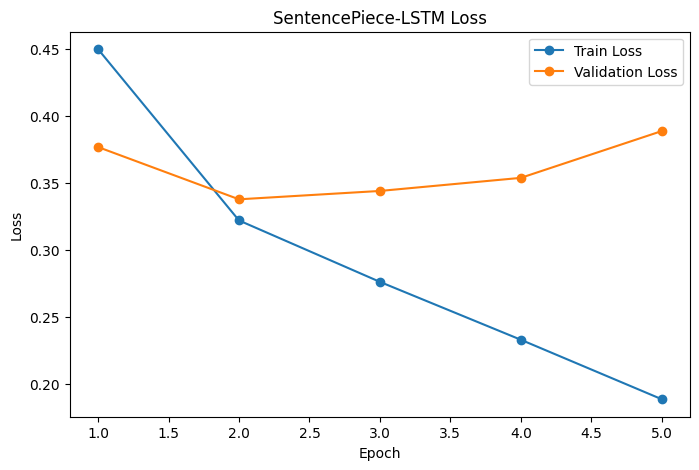

In [23]:
import matplotlib.pyplot as plt


epochs = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SentencePiece-LSTM Loss")
plt.legend()
plt.show()

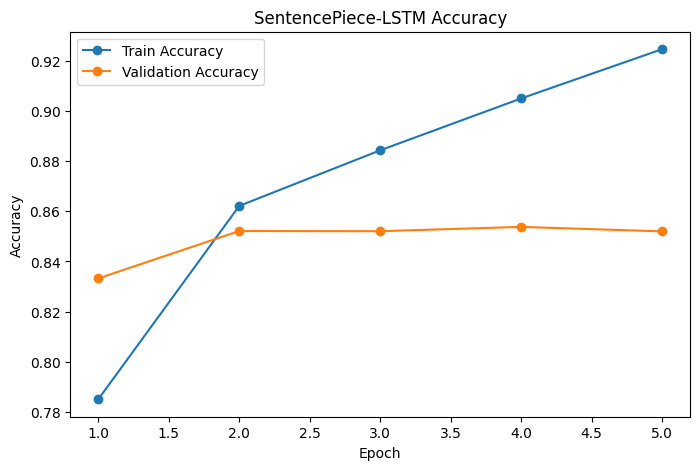

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_acc"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    epochs,
    history["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("SentencePiece-LSTM Accuracy")
plt.legend()
plt.show()

### 딱 한번의 테스트!

In [25]:
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

test_loss, test_acc = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(
    f"Test Loss     : {test_loss:.4f}"
)

print(
    f"Test Accuracy : {test_acc:.4%}"
)

Test Loss     : 0.3533
Test Accuracy : 85.3268%


### SentencePiece-LSTM 학습 결과

SentencePiece Unigram Tokenizer로 변환한 NSMC 데이터를
Embedding 및 단방향 LSTM 기반 감성분류 모델에 적용했다.

학습이 진행되면서 Train Loss는 지속적으로 감소하고
Train Accuracy는 약 78.5%에서 92% 이상으로 증가하여
모델이 정상적으로 학습되고 있음을 확인하였다.

Validation Accuracy는 Epoch 1의 83.33%에서 약 85% 수준까지
향상된 후 정체되었다. 반면 Epoch 2 이후 Train 성능은 계속
개선되지만 Validation Loss는 다시 증가하는 경향을 보여,
후반 Epoch에서 (OMG) 과적합이 시작되는 것을 확인할 수 있었다!

Validation Accuracy를 기준으로 가장 성능이 좋은 모델을 저장하여
최종 Test 데이터에 평가한 결과는 다음과 같다.

- Test Loss: 0.3533
- Test Accuracy: 85.3268%

프로젝트 평가 기준인 Test Accuracy 80% 이상을 달성하였으며,
SentencePiece로 구축한 Tokenizer가 LSTM 기반 자연어처리 모델과
정상적으로 결합되어 감성분류에 활용될 수 있음을 확인했다.

# 자 이제 비교 실험을 어떻게 세팅할 것인가?

| 실험    | Tokenizer     | 설정                   | 역할             |
| ----- | ------------- | -------------------- | -------------- |
| **A** | SentencePiece | Unigram / vocab 8000 | 현재 Baseline ✅  |
| **B** | 형태소 분석기       | 하나만 선택               | 형태소 vs Subword |
| **C** | SentencePiece | BPE / vocab 8000     | Unigram vs BPE |




```
A vs B

SentencePiece Subword
        vs
한국어 형태소 Tokenization

→ Tokenization 단위 자체의 차이


A vs C

SentencePiece Unigram
        vs
SentencePiece BPE

→ 같은 SentencePiece에서
   subword 학습 알고리즘 차이
```



## 공정한 비교를 위해 고정할 것:
SEED = 21

BATCH_SIZE = 64
MAX_LEN = 80

EMBEDDING_DIM = 128
HIDDEN_DIM = 128

DROPOUT = 0.3
LEARNING_RATE = 1e-3
NUM_CLASSES = 2

TOTAL_EPOCHS = 5

그리고 `데이터`도 고정~

Model Train : 130,798
Validation  : 14,533
Test        : 49,110

## 17. 형태소 기반 Tokenizer 비교 — MeCab

SentencePiece Subword Tokenizer와 한국어 형태소 기반 Tokenizer의
성능 차이를 비교하기 위해 MeCab-ko를 사용한다.

공정한 비교를 위해 Tokenizer를 제외한 다음 조건은 동일하게 유지한다.

- 동일 Train / Validation / Test split
- Vocabulary size: 8,000
- Maximum sequence length: 80
- Embedding dimension: 128
- LSTM hidden dimension: 128
- Batch size: 64
- Learning rate: 0.001
- Epoch: 5
- Random seed: 21

품사에 따른 선택적 필터링은 수행하지 않고,
MeCab이 분석한 전체 형태소 sequence를 사용한다.

In [26]:
!pip install -q konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 37.7 MB/s eta 0:00:00


In [29]:
!pip install -q -U mecab-python3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.4/591.4 kB 22.5 MB/s eta 0:00:00


In [30]:
import MeCab

print("MeCab Python binding ready")
print("MeCab version:", MeCab.VERSION)

MeCab Python binding ready
MeCab version: 0.996


In [32]:
!pip install -q -U python-mecab-ko

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.6/579.6 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 35.2 MB/s eta 0:00:00


In [33]:
from mecab import MeCab

mecab = MeCab()

print("MeCab ready")

sample = "거참 되게 할 게 많네, 이해할 건 더 많고.."

print("Morphs:", mecab.morphs(sample))
print("POS   :", mecab.pos(sample))

MeCab ready
Morphs: ['거참', '되게', '할', '게', '많', '네', ',', '이해', '할', '건', '더', '많', '고', '.', '.']
POS   : [('거참', 'IC'), ('되게', 'MAG'), ('할', 'VV+ETM'), ('게', 'NNB+JKS'), ('많', 'VA'), ('네', 'EF'), (',', 'SC'), ('이해', 'NNG'), ('할', 'XSV+ETM'), ('건', 'NNB+JX'), ('더', 'MAG'), ('많', 'VA'), ('고', 'EC'), ('.', 'SF'), ('.', 'SF')]


### MeCab 환경 구성

현재 Colab의 Python 3.12 환경에서는 KoNLPy의 `Mecab`
wrapper와 Python binding 간 호환 문제가 발생했다.

따라서 형태소 분석 알고리즘은 동일한 MeCab-ko를 유지하 동일한 MeCab-ko를 유지하되,
Python 3.12용 binary wheel을 제공하는 `python-mecab-ko`
binding을 사용했다.

Tokenizer 비교에서는 MeCab의 `morphs()` 결과 전체를 사용하며,
품사 기반 추가 필터링은 적용하지 않는다.

## 18. MeCab 샘플 분석 및 Vocabulary 설계

SentencePiece와 형태소 기반 Tokenizer를 공정하게 비교하기 위해
동일한 `model_train_df`에서 MeCab 형태소 분석 결과를 확인한다.

먼저 Train 데이터 1,000개만 분석하여 다음을 점검한다.

- 리뷰당 형태소 수
- 전체 형태소 종류 수
- 빈도가 높은 형태소
- 문장부호·감정표현의 보존 여부

이후 Train 데이터에서 자주 등장하는 형태소를 기준으로
Vocabulary size 8,000을 구성한다.

특수 토큰은 다음과 같이 고정한다.

- `<pad>` = 0
- `<unk>` = 1

따라서 실제 MeCab 형태소 vocabulary는 빈도 상위 7,998개를 사용한다.

In [34]:
from collections import Counter

sample_mecab_df = model_train_df.iloc[:1000].copy()

sample_mecab_tokens = []
sample_mecab_lengths = []
sample_counter = Counter()

for text in sample_mecab_df["document"]:
    tokens = mecab.morphs(text)

    sample_mecab_tokens.append(tokens)
    sample_mecab_lengths.append(len(tokens))
    sample_counter.update(tokens)

print("Sample reviews:", len(sample_mecab_df))
print("Unique morphemes:", len(sample_counter))
print()

print("Most common 30 morphemes:")
for token, count in sample_counter.most_common(30):
    print(f"{token!r:12s} {count}")

Sample reviews: 1000
Unique morphemes: 3668

Most common 30 morphemes:
'.'          1106
'이'          545
'는'          445
'다'          389
'영화'         383
'고'          355
'하'          343
'도'          252
'의'          243
'은'          235
'가'          214
'에'          205
'을'          197
'..'         172
'들'          166
'보'          165
','          159
'한'          158
'게'          155
'지'          130
'!'          122
'있'          122
'없'          117
'를'          110
'?'          100
'만'          83
'는데'         83
'었'          82
'안'          79
'좋'          78


In [35]:
# 형태소 길이도 같이 확인
sample_mecab_lengths = np.array(sample_mecab_lengths)

print("Mean :", sample_mecab_lengths.mean())
print("50%  :", np.percentile(sample_mecab_lengths, 50))
print("75%  :", np.percentile(sample_mecab_lengths, 75))
print("90%  :", np.percentile(sample_mecab_lengths, 90))
print("95%  :", np.percentile(sample_mecab_lengths, 95))
print("99%  :", np.percentile(sample_mecab_lengths, 99))
print("Max  :", sample_mecab_lengths.max())

Mean : 19.008
50%  : 14.0
75%  : 23.25
90%  : 40.0
95%  : 58.0
99%  : 73.0
Max  : 87


In [36]:
# 실제로 SP 이랑 mecab 이랑 하나 두고 비교해보자
compare_text = model_train_df.iloc[0]["document"]

sp_tokens = sp.encode(
    compare_text,
    out_type=str
)

mecab_tokens = mecab.morphs(
    compare_text
)

print("원문:")
print(compare_text)

print()
print("SentencePiece:")
print(sp_tokens)
print("Token count:", len(sp_tokens))

print()
print("MeCab:")
print(mecab_tokens)
print("Token count:", len(mecab_tokens))

원문:
아 더빙.. 진짜 짜증나네요 목소리

SentencePiece:
['▁아', '▁더빙', '..', '▁진짜', '▁짜증나', '네요', '▁목소리']
Token count: 7

MeCab:
['아', '더', '빙', '.', '.', '진짜', '짜증', '나', '네요', '목소리']
Token count: 10


In [37]:
MECAB_VOCAB_SIZE = 8000
MECAB_PAD_ID = 0
MECAB_UNK_ID = 1

NUM_REAL_TOKENS = MECAB_VOCAB_SIZE - 2

print(NUM_REAL_TOKENS)
# 7998

7998


In [38]:
# 전체 Train용 vocab 구축 코드
mecab_counter = Counter()

for text in model_train_df["document"]:
    tokens = mecab.morphs(text)
    mecab_counter.update(tokens)

In [39]:
most_common_tokens = mecab_counter.most_common(
    MECAB_VOCAB_SIZE - 2
)

mecab_word_index = {
    "<pad>": MECAB_PAD_ID,
    "<unk>": MECAB_UNK_ID,
}

for idx, (token, count) in enumerate(
    most_common_tokens,
    start=2
):
    mecab_word_index[token] = idx

In [40]:
mecab_index_word = {
    idx: token
    for token, idx
    in mecab_word_index.items()
}

In [41]:
len(mecab_word_index)


8000

실험이 길어지니 캐시처리할 것도 많아지네요....

## 19. MeCab 전체 코퍼스 토큰화 및 Cache

SentencePiece baseline과 동일한 개발 코퍼스를 사용하기 위해
`train_clean` 전체에서 MeCab 형태소 vocabulary를 구축한다.

- Vocabulary 구축 corpus: `train_clean`
- Test 데이터는 vocabulary 구축에 사용하지 않음
- `<pad>` = 0
- `<unk>` = 1
- 빈도 상위 7,998개 형태소 사용
- Total vocabulary size = 8,000

MeCab 형태소 분석은 연산 비용이 있으므로 Train/Validation/Test
분석 결과를 Drive에 저장하여 이후 학습에서 재사용한다.

In [42]:
import pickle
from pathlib import Path

MECAB_CACHE_DIR = DATA_DIR / "mecab_cache"
MECAB_MODEL_DIR = MODELS_DIR / "mecab"

MECAB_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MECAB_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TRAIN_CLEAN_TOKENS_PATH = (
    MECAB_CACHE_DIR / "train_clean_tokens.pkl"
)

MODEL_TRAIN_TOKENS_PATH = (
    MECAB_CACHE_DIR / "model_train_tokens.pkl"
)

VAL_TOKENS_PATH = (
    MECAB_CACHE_DIR / "val_tokens.pkl"
)

TEST_TOKENS_PATH = (
    MECAB_CACHE_DIR / "test_tokens.pkl"
)

In [43]:
def tokenize_with_mecab(texts, cache_path):
    """
    MeCab 형태소 분석 결과가 cache에 있으면 불러오고,
    없으면 새로 분석하여 저장한다.
    """

    if cache_path.exists():

        print(f"[LOAD CACHE] {cache_path.name}")

        with open(cache_path, "rb") as f:
            tokenized = pickle.load(f)

    else:

        print(f"[TOKENIZING] {cache_path.name}")

        tokenized = [
            mecab.morphs(text)
            for text in texts
        ]

        with open(cache_path, "wb") as f:
            pickle.dump(tokenized, f)

        print(f"[SAVED] {cache_path}")

    return tokenized

In [44]:
train_clean_mecab_tokens = tokenize_with_mecab(
    train_clean["document"].tolist(),
    TRAIN_CLEAN_TOKENS_PATH
)

print(
    "Tokenized train_clean:",
    len(train_clean_mecab_tokens)
)

[TOKENIZING] train_clean_tokens.pkl
[SAVED] /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/mecab_cache/train_clean_tokens.pkl
Tokenized train_clean: 145331


In [45]:
from collections import Counter

mecab_counter = Counter()

for tokens in train_clean_mecab_tokens:
    mecab_counter.update(tokens)

print(
    "Total unique MeCab morphemes:",
    len(mecab_counter)
)

print()
print("Most common 30:")

for token, count in mecab_counter.most_common(30):
    print(f"{token!r:12s} {count:,}")

Total unique MeCab morphemes: 53955

Most common 30:
'.'          159,140
'이'          73,255
'는'          66,615
'영화'         57,235
'다'          54,829
'고'          47,164
'하'          44,338
'도'          34,010
'의'          33,523
'가'          33,248
'은'          31,055
'에'          30,678
'을'          29,797
'보'          25,582
'한'          25,159
'..'         22,610
'게'          22,125
','          22,034
'들'          21,466
'!'          19,206
'지'          19,120
'를'          17,061
'있'          16,666
'없'          15,761
'?'          15,302
'좋'          13,638
'나'          12,571
'었'          12,155
'만'          11,657
'는데'         11,512


In [46]:
MECAB_VOCAB_SIZE = 8000
MECAB_PAD_ID = 0
MECAB_UNK_ID = 1

NUM_MECAB_TOKENS = (
    MECAB_VOCAB_SIZE - 2
)

most_common_tokens = (
    mecab_counter.most_common(
        NUM_MECAB_TOKENS
    )
)

mecab_word_index = {
    "<pad>": MECAB_PAD_ID,
    "<unk>": MECAB_UNK_ID,
}

for idx, (token, _) in enumerate(
    most_common_tokens,
    start=2
):
    mecab_word_index[token] = idx


mecab_index_word = {
    idx: token
    for token, idx
    in mecab_word_index.items()
}

print(
    "MeCab vocabulary size:",
    len(mecab_word_index)
)

print(
    "PAD:",
    mecab_word_index["<pad>"]
)

print(
    "UNK:",
    mecab_word_index["<unk>"]
)

MeCab vocabulary size: 8000
PAD: 0
UNK: 1


In [47]:
import json

MECAB_VOCAB_PATH = (
    MECAB_MODEL_DIR / "mecab_vocab_8000.json"
)

with open(
    MECAB_VOCAB_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        mecab_word_index,
        f,
        ensure_ascii=False,
        indent=2
    )

print("Saved:", MECAB_VOCAB_PATH)

Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/mecab/mecab_vocab_8000.json


In [48]:
# 똑같은 분할 반영
model_train_mecab_tokens = tokenize_with_mecab(
    model_train_df["document"].tolist(),
    MODEL_TRAIN_TOKENS_PATH
)

val_mecab_tokens = tokenize_with_mecab(
    val_df["document"].tolist(),
    VAL_TOKENS_PATH
)

test_mecab_tokens = tokenize_with_mecab(
    test_clean["document"].tolist(),
    TEST_TOKENS_PATH
)

print(
    len(model_train_mecab_tokens),
    len(val_mecab_tokens),
    len(test_mecab_tokens)
)

[TOKENIZING] model_train_tokens.pkl
[SAVED] /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/mecab_cache/model_train_tokens.pkl
[TOKENIZING] val_tokens.pkl
[SAVED] /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/mecab_cache/val_tokens.pkl
[TOKENIZING] test_tokens.pkl
[SAVED] /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/mecab_cache/test_tokens.pkl
130798 14533 49110


In [49]:
# 자이제 토큰에서 ID로 변환~
sp.encode(text, out_type=int)

[277, 6, 687, 698, 24, 56, 303, 53, 452, 5700, 6]

In [50]:
def mecab_tokens_to_ids(
    tokens,
    word_index
):
    return [
        word_index
        .get(
            token,
            MECAB_UNK_ID
        )
        for token in tokens
    ]

In [51]:
# 샘플 확인
sample_tokens = mecab.morphs(
    "지금은 오후 네시 삼십팔분. 프로젝트 두 개 하는 건 욕심이었다."
)

sample_ids = mecab_tokens_to_ids(
    sample_tokens,
    mecab_word_index
)

print("Tokens:", sample_tokens)
print("IDs   :", sample_ids)

Tokens: ['지금', '은', '오후', '네', '시', '삼', '십', '팔', '분', '.', '프로젝트', '두', '개', '하', '는', '건', '욕심', '이', '었', '다', '.']
IDs   : [161, 12, 7527, 52, 170, 917, 1077, 921, 149, 2, 4905, 205, 135, 8, 4, 146, 2177, 3, 29, 6, 2]


In [52]:
# MAX 80 커버리지 수준 확인
mecab_train_lengths = np.array(
    [
        len(tokens)
        for tokens
        in model_train_mecab_tokens
    ]
)

print(
    "Mean:",
    mecab_train_lengths.mean()
)

print(
    "50%:",
    np.percentile(
        mecab_train_lengths, 50
    )
)

print(
    "75%:",
    np.percentile(
        mecab_train_lengths, 75
    )
)

print(
    "90%:",
    np.percentile(
        mecab_train_lengths, 90
    )
)

print(
    "95%:",
    np.percentile(
        mecab_train_lengths, 95
    )
)

print(
    "99%:",
    np.percentile(
        mecab_train_lengths, 99
    )
)

print(
    "Max:",
    mecab_train_lengths.max()
)

mecab_coverage_80 = (
    mecab_train_lengths <= MAX_LEN
).mean()

print()
print(
    "MAX_LEN=80 coverage:",
    f"{mecab_coverage_80:.4%}"
)

Mean: 18.808980259636996
50%: 14.0
75%: 23.0
90%: 39.0
95%: 56.0
99%: 73.0
Max: 116

MAX_LEN=80 coverage: 99.8555%


In [53]:
# UNK 등등도 확인
def calculate_unk_stats(
    tokenized_corpus,
    word_index
):
    total_tokens = 0
    unk_tokens = 0
    sentences_with_unk = 0

    for tokens in tokenized_corpus:

        ids = mecab_tokens_to_ids(
            tokens,
            word_index
        )

        current_unk = ids.count(
            MECAB_UNK_ID
        )

        total_tokens += len(ids)
        unk_tokens += current_unk

        if current_unk > 0:
            sentences_with_unk += 1

    return {
        "total_tokens": total_tokens,

        "unk_tokens": unk_tokens,

        "unk_rate": (
            unk_tokens / total_tokens
            if total_tokens > 0
            else 0
        ),

        "sentences_with_unk":
            sentences_with_unk,

        "sentence_unk_rate": (
            sentences_with_unk
            / len(tokenized_corpus)
        )
    }

In [54]:
mecab_train_unk = calculate_unk_stats(
    model_train_mecab_tokens,
    mecab_word_index
)

mecab_val_unk = calculate_unk_stats(
    val_mecab_tokens,
    mecab_word_index
)

mecab_test_unk = calculate_unk_stats(
    test_mecab_tokens,
    mecab_word_index
)

print("TRAIN:", mecab_train_unk)
print()
print("VALID:", mecab_val_unk)
print()
print("TEST :", mecab_test_unk)

TRAIN: {'total_tokens': 2460177, 'unk_tokens': 111349, 'unk_rate': 0.04526056458539365, 'sentences_with_unk': 59161, 'sentence_unk_rate': 0.45230813926818453}

VALID: {'total_tokens': 274605, 'unk_tokens': 12612, 'unk_rate': 0.04592778718522969, 'sentences_with_unk': 6565, 'sentence_unk_rate': 0.4517305442785385}

TEST : {'total_tokens': 918661, 'unk_tokens': 43145, 'unk_rate': 0.0469650937614637, 'sentences_with_unk': 22695, 'sentence_unk_rate': 0.4621258399511301}


| 지표                  | SentencePiece Unigram 8K |                           MeCab 8K |
| ------------------- | -----------------------: | ---------------------------------: |
| Vocab size          |                    8,000 |                              8,000 |
| MAX_LEN=80 coverage |                 99.6773% |                       **99.8555%** |
| Token UNK rate      |               **0.094%** | Train **4.526%** / Test **4.697%** |
| 문장 중 UNK 포함 비율      |                **1.47%** | Train **45.23%** / Test **46.21%** |
| Test Accuracy       |             **85.3268%** |                              학습 예정 |


단일 샘플에서는 MeCab이 SentencePiece보다 더 많은 token으로
분절되었으나, 전체 Train corpus를 분석한 결과
MAX_LEN=80 이내에 포함되는 비율은 MeCab이 99.8555%로
SentencePiece의 99.6773%보다 오히려 높았다.

따라서 개별 문장의 token 수만으로 전체 tokenizer의
sequence length 특성을 판단하기 어렵고,
corpus 전체 분포를 확인할 필요가 있다.

## 20. MeCab-LSTM 감성분류 실험

MeCab 형태소 분석 결과를 SentencePiece 실험과 동일한
LSTM 분류 모델에 적용한다.

Tokenizer 이외의 조건을 동일하게 유지하여
분류 성능 차이가 Tokenization 방식과 어떤 관계를 보이는지 비교한다.

- Vocabulary size: 8,000
- MAX_LEN: 80
- Embedding dimension: 128
- Hidden dimension: 128
- Dropout: 0.3
- Batch size: 64
- Learning rate: 0.001
- Epoch: 5
- Seed: 21

In [55]:
class NSMCMecabDataset(Dataset):
    def __init__(
        self,
        tokenized_texts,
        labels,
        word_index,
        max_len=MAX_LEN
    ):
        self.tokenized_texts = tokenized_texts
        self.labels = labels
        self.word_index = word_index
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        tokens = self.tokenized_texts[idx]

        token_ids = [
            self.word_index.get(
                token,
                MECAB_UNK_ID
            )
            for token in tokens
        ]

        # 극히 예외적으로 token이 없을 경우
        if len(token_ids) == 0:
            token_ids = [MECAB_UNK_ID]

        valid_length = min(
            len(token_ids),
            self.max_len
        )

        token_ids = token_ids[:self.max_len]

        input_ids = torch.full(
            (self.max_len,),
            MECAB_PAD_ID,
            dtype=torch.long
        )

        input_ids[:valid_length] = torch.tensor(
            token_ids,
            dtype=torch.long
        )

        return {
            "input_ids": input_ids,
            "length": torch.tensor(
                valid_length,
                dtype=torch.long
            ),
            "label": torch.tensor(
                self.labels[idx],
                dtype=torch.long
            )
        }

In [56]:
# 데이터셋 생성
mecab_train_dataset = NSMCMecabDataset(
    model_train_mecab_tokens,
    model_train_df["label"].tolist(),
    mecab_word_index
)

mecab_val_dataset = NSMCMecabDataset(
    val_mecab_tokens,
    val_df["label"].tolist(),
    mecab_word_index
)

mecab_test_dataset = NSMCMecabDataset(
    test_mecab_tokens,
    test_clean["label"].tolist(),
    mecab_word_index
)

print(
    len(mecab_train_dataset),
    len(mecab_val_dataset),
    len(mecab_test_dataset)
)

130798 14533 49110


In [57]:
# 동일 시드로 데이터로더
mecab_generator = torch.Generator()
mecab_generator.manual_seed(SEED)

mecab_train_loader = DataLoader(
    mecab_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    generator=mecab_generator
)

mecab_val_loader = DataLoader(
    mecab_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

mecab_test_loader = DataLoader(
    mecab_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [58]:
# 한배치테스트
batch = next(iter(mecab_train_loader))

print("input_ids:", batch["input_ids"].shape)
print("lengths  :", batch["length"].shape)
print("labels   :", batch["label"].shape)

input_ids: torch.Size([64, 80])
lengths  : torch.Size([64])
labels   : torch.Size([64])


In [59]:
# 모델 초기화
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

mecab_model = SentimentLSTM(
    vocab_size=MECAB_VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    pad_id=MECAB_PAD_ID,
    dropout=DROPOUT
).to(device)

mecab_criterion = nn.CrossEntropyLoss()

mecab_optimizer = optim.Adam(
    mecab_model.parameters(),
    lr=LEARNING_RATE
)

print(mecab_model)
print(
    "Device:",
    next(mecab_model.parameters()).device
)

SentimentLSTM(
  (embedding): Embedding(8000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)
Device: cuda:0




```
SentencePiece Unigram 8K             MeCab 8K
─────────────────────               ─────────────
Train 130,798                =       Train 130,798
Val    14,533                =       Val    14,533
Test   49,110                =       Test   49,110

Vocab 8,000                  =       Vocab 8,000
MAX_LEN 80                   =       MAX_LEN 80
Embedding 128                =       Embedding 128
LSTM 128                     =       LSTM 128
Dropout 0.3                  =       Dropout 0.3
Adam 1e-3                    =       Adam 1e-3
Seed 21                      =       Seed 21
Epoch 5                      =       Epoch 5

Tokenizer만 다름
```



In [60]:
# Mecab LSTM 정식 학습
mecab_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

MECAB_BEST_MODEL_PATH = (
    MODELS_DIR / "sentiment_lstm_mecab_8000_best.pt"
)

mecab_best_val_acc = 0.0

TOTAL_EPOCHS = 5

In [61]:
for epoch in range(1, TOTAL_EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        mecab_model,
        mecab_train_loader,
        mecab_criterion,
        mecab_optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        mecab_model,
        mecab_val_loader,
        mecab_criterion,
        device
    )

    mecab_history["train_loss"].append(train_loss)
    mecab_history["train_acc"].append(train_acc)
    mecab_history["val_loss"].append(val_loss)
    mecab_history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch}/{TOTAL_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4%} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4%}"
    )

    if val_acc > mecab_best_val_acc:

        mecab_best_val_acc = val_acc

        torch.save(
            mecab_model.state_dict(),
            MECAB_BEST_MODEL_PATH
        )

        print(
            f"  → Best model updated: "
            f"{mecab_best_val_acc:.4%}"
        )

Epoch 1/5 | Train Loss: 0.4073 | Train Acc: 81.1526% | Val Loss: 0.3396 | Val Acc: 85.1786%
  → Best model updated: 85.1786%
Epoch 2/5 | Train Loss: 0.3063 | Train Acc: 86.9998% | Val Loss: 0.3163 | Val Acc: 86.4653%
  → Best model updated: 86.4653%
Epoch 3/5 | Train Loss: 0.2621 | Train Acc: 89.1894% | Val Loss: 0.3108 | Val Acc: 86.5754%
  → Best model updated: 86.5754%
Epoch 4/5 | Train Loss: 0.2268 | Train Acc: 90.7858% | Val Loss: 0.3089 | Val Acc: 86.7543%
  → Best model updated: 86.7543%
Epoch 5/5 | Train Loss: 0.1916 | Train Acc: 92.3814% | Val Loss: 0.3304 | Val Acc: 86.8644%
  → Best model updated: 86.8644%


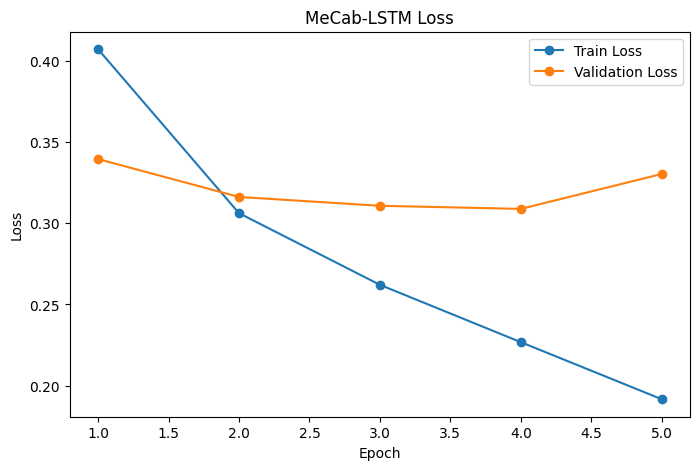

In [62]:
# 학습곡선 lo0sss
mecab_epochs = range(
    1,
    len(mecab_history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    mecab_epochs,
    mecab_history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    mecab_epochs,
    mecab_history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MeCab-LSTM Loss")
plt.legend()
plt.show()

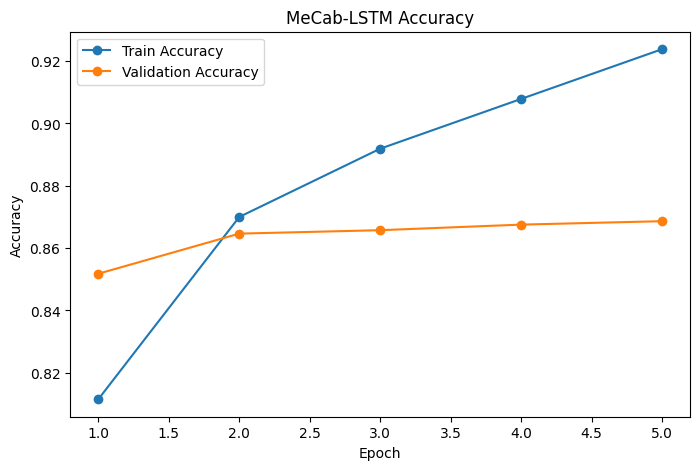

In [63]:
# 학습곡선 accu
plt.figure(figsize=(8, 5))

plt.plot(
    mecab_epochs,
    mecab_history["train_acc"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    mecab_epochs,
    mecab_history["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MeCab-LSTM Accuracy")
plt.legend()
plt.show()

In [64]:
# Best MODEL 1회 ㅆㄸㄴㅆ TEST
mecab_model.load_state_dict(
    torch.load(
        MECAB_BEST_MODEL_PATH,
        map_location=device
    )
)

mecab_test_loss, mecab_test_acc = evaluate(
    mecab_model,
    mecab_test_loader,
    mecab_criterion,
    device
)

print(
    f"MeCab Test Loss     : "
    f"{mecab_test_loss:.4f}"
)

print(
    f"MeCab Test Accuracy : "
    f"{mecab_test_acc:.4%}"
)

print(
    f"Best Validation Acc : "
    f"{mecab_best_val_acc:.4%}"
)

MeCab Test Loss     : 0.3397
MeCab Test Accuracy : 86.6158%
Best Validation Acc : 86.8644%


| 지표                  | SentencePiece Unigram 8K |         MeCab 8K |
| ------------------- | -----------------------: | ---------------: |
| Vocab size          |                    8,000 |            8,000 |
| MAX_LEN=80 coverage |                 99.6773% |     **99.8555%** |
| Token UNK rate      |               **0.094%** | Test **4.6965%** |
| UNK 포함 문장           |                **1.47%** |  Test **46.21%** |
| Best Validation Acc |                   약 85%대 |     **86.8644%** |
| Test Loss           |                   0.3533 |       **0.3397** |
| Test Accuracy       |                 85.3268% |     **86.6158%** |


MeCab의 형태소 단위가 성능 향상의 원인이라고 단정할 수는 없지만, 높은 UNK 비율에도 불구하고 더 높은 분류 정확도를 기록한 결과를 볼 때, NSMC 감성분류에서는 자주 등장하는 한국어 형태소를 명시적으로 분리하는 방식이 LSTM의 학습에 유리하게 작용했을 가능성이 있다.

### SentencePiece Unigram과 MeCab 비교 결과

동일한 데이터 분할과 동일한 LSTM 구조를 사용하여
SentencePiece Unigram 8K와 MeCab 8K Tokenizer를 비교했다.

MeCab은 Test 기준 약 4.70%의 token이 `<unk>`로 변환되었으며,
약 46.21%의 Test 문장에 하나 이상의 `<unk>`가 포함됐다.
이는 SentencePiece의 매우 낮은 UNK 비율과 큰 차이를 보였다.

그러나 최종 감성분류 성능에서는 MeCab이 더 높은 결과를 기록했다.

- SentencePiece Unigram Test Accuracy: 85.3268%
- MeCab Test Accuracy: 86.6158%

따라서 낮은 UNK 비율이 반드시 더 높은 downstream 분류 성능으로
직결되는 것은 아님을 확인했다.

MeCab은 높은 UNK 비율에도 불구하고 한국어 형태소 경계를
명시적으로 분리하며, 빈도가 높은 감성 관련 형태소를 효과적으로
표현했기 때문에 NSMC 감성분류에서 유리하게 작용했을 가능성이 있다.

다만 본 실험만으로 성능 차이의 원인을 특정 요소에 귀속할 수 없으므로,
Tokenizer의 분절 방식, sequence length, vocabulary 구성,
UNK 특성이 함께 영향을 미친 결과로 해석한다.

또한 MeCab은 MAX_LEN=80에서 99.8555%의 문장을 보존하여,
SentencePiece Unigram의 99.6773%와 마찬가지로
sequence truncation의 영향은 매우 제한적이었다.

# 마지막 실험 — SentencePiece BPE 8K

In [67]:
# BPE 모델 학습
SPM_BPE_MODEL_PREFIX = (
    SPM_DIR / "nsmc_bpe_8000"
)

SPM_BPE_MODEL_PATH = Path(
    str(SPM_BPE_MODEL_PREFIX) + ".model"
)

SPM_BPE_VOCAB_PATH = Path(
    str(SPM_BPE_MODEL_PREFIX) + ".vocab"
)

In [70]:
# SentencePiece BPE 학습에 필요한 경로 복구

SPM_CORPUS_PATH = DATA_DIR / "nsmc_spm_train.txt"

SPM_DIR = MODELS_DIR / "sentencepiece"
SPM_DIR.mkdir(parents=True, exist_ok=True)

SPM_BPE_MODEL_PREFIX = (
    SPM_DIR / "nsmc_bpe_8000"
)

SPM_BPE_MODEL_PATH = Path(
    str(SPM_BPE_MODEL_PREFIX) + ".model"
)

SPM_BPE_VOCAB_PATH = Path(
    str(SPM_BPE_MODEL_PREFIX) + ".vocab"
)

print("Corpus :", SPM_CORPUS_PATH)
print("Exists :", SPM_CORPUS_PATH.exists())

print()
print("BPE model path:", SPM_BPE_MODEL_PATH)

Corpus : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/nsmc_spm_train.txt
Exists : True

BPE model path: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/sentencepiece/nsmc_bpe_8000.model


In [71]:
if not SPM_BPE_MODEL_PATH.exists():

    print("Training SentencePiece BPE 8K...")

    spm.SentencePieceTrainer.train(
        input=str(SPM_CORPUS_PATH),
        model_prefix=str(SPM_BPE_MODEL_PREFIX),

        vocab_size=8000,
        model_type="bpe",

        character_coverage=0.9995,

        pad_id=0,
        unk_id=1,
        bos_id=-1,
        eos_id=-1,
    )

    print("BPE model trained")

else:
    print("Existing BPE model found")

Training SentencePiece BPE 8K...
BPE model trained


In [72]:
print(
    "Model exists:",
    SPM_BPE_MODEL_PATH.exists()
)

print(
    "Vocab exists:",
    SPM_BPE_VOCAB_PATH.exists()
)

print(
    "Model:",
    SPM_BPE_MODEL_PATH
)

print(
    "Vocab:",
    SPM_BPE_VOCAB_PATH
)

Model exists: True
Vocab exists: True
Model: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/sentencepiece/nsmc_bpe_8000.model
Vocab: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/sentencepiece/nsmc_bpe_8000.vocab


In [73]:
sp_bpe = spm.SentencePieceProcessor(
    model_file=str(SPM_BPE_MODEL_PATH)
)

print(
    "Vocabulary size:",
    sp_bpe.get_piece_size()
)

print("PAD:", sp_bpe.pad_id())
print("UNK:", sp_bpe.unk_id())

Vocabulary size: 8000
PAD: 0
UNK: 1


In [74]:
compare_text = "정말 마지막 실험인데 과연 어떻게 나올지?"

unigram_tokens = sp.encode(
    compare_text,
    out_type=str
)

bpe_tokens = sp_bpe.encode(
    compare_text,
    out_type=str
)

mecab_tokens = mecab.morphs(
    compare_text
)

print("원문:")
print(compare_text)

print()
print("SentencePiece Unigram:")
print(unigram_tokens)
print("Count:", len(unigram_tokens))

print()
print("SentencePiece BPE:")
print(bpe_tokens)
print("Count:", len(bpe_tokens))

print()
print("MeCab:")
print(mecab_tokens)
print("Count:", len(mecab_tokens))

원문:
정말 마지막 실험인데 과연 어떻게 나올지?

SentencePiece Unigram:
['▁정말', '▁마지막', '▁실험', '인데', '▁과연', '▁어떻게', '▁나올', '지', '?']
Count: 9

SentencePiece BPE:
['▁정말', '▁마지막', '▁실험', '인데', '▁과연', '▁어떻게', '▁나올', '지', '?']
Count: 9

MeCab:
['정말', '마지막', '실험', '인데', '과연', '어떻게', '나올', '지', '?']
Count: 9


In [75]:
bpe_train_lengths = np.array([
    len(
        sp_bpe.encode(
            text,
            out_type=int
        )
    )
    for text in model_train_df["document"]
])

print("Mean :", bpe_train_lengths.mean())
print("50%  :", np.percentile(bpe_train_lengths, 50))
print("75%  :", np.percentile(bpe_train_lengths, 75))
print("90%  :", np.percentile(bpe_train_lengths, 90))
print("95%  :", np.percentile(bpe_train_lengths, 95))
print("99%  :", np.percentile(bpe_train_lengths, 99))
print("Max  :", bpe_train_lengths.max())

bpe_coverage_80 = (
    bpe_train_lengths <= MAX_LEN
).mean()

print()
print(
    "MAX_LEN=80 coverage:",
    f"{bpe_coverage_80:.4%}"
)

Mean : 17.065941375250386
50%  : 13.0
75%  : 21.0
90%  : 36.0
95%  : 51.0
99%  : 70.0
Max  : 130

MAX_LEN=80 coverage: 99.7683%


In [76]:
def calculate_sp_unk_stats(
    texts,
    tokenizer
):
    total_tokens = 0
    unk_tokens = 0
    sentences_with_unk = 0

    unk_id = tokenizer.unk_id()

    for text in texts:

        ids = tokenizer.encode(
            text,
            out_type=int
        )

        current_unk = ids.count(
            unk_id
        )

        total_tokens += len(ids)
        unk_tokens += current_unk

        if current_unk > 0:
            sentences_with_unk += 1

    return {
        "total_tokens": total_tokens,
        "unk_tokens": unk_tokens,
        "unk_rate": (
            unk_tokens / total_tokens
            if total_tokens > 0
            else 0
        ),
        "sentences_with_unk": sentences_with_unk,
        "sentence_unk_rate": (
            sentences_with_unk / len(texts)
        )
    }

In [77]:
bpe_train_unk = calculate_sp_unk_stats(
    model_train_df["document"].tolist(),
    sp_bpe
)

bpe_val_unk = calculate_sp_unk_stats(
    val_df["document"].tolist(),
    sp_bpe
)

bpe_test_unk = calculate_sp_unk_stats(
    test_clean["document"].tolist(),
    sp_bpe
)

print("TRAIN:", bpe_train_unk)
print()
print("VALID:", bpe_val_unk)
print()
print("TEST :", bpe_test_unk)

TRAIN: {'total_tokens': 2232191, 'unk_tokens': 2138, 'unk_rate': 0.0009578033420975176, 'sentences_with_unk': 1935, 'sentence_unk_rate': 0.014793804186608358}

VALID: {'total_tokens': 249617, 'unk_tokens': 239, 'unk_rate': 0.0009574668391976508, 'sentences_with_unk': 199, 'sentence_unk_rate': 0.013692974609509393}

TEST : {'total_tokens': 833753, 'unk_tokens': 896, 'unk_rate': 0.0010746588018273997, 'sentences_with_unk': 792, 'sentence_unk_rate': 0.016127061698228466}


In [78]:
# BPE 길이 분석
bpe_train_lengths = np.array([
    len(sp_bpe.encode(text, out_type=int))
    for text in model_train_df["document"]
])

print("Mean :", bpe_train_lengths.mean())
print("50%  :", np.percentile(bpe_train_lengths, 50))
print("75%  :", np.percentile(bpe_train_lengths, 75))
print("90%  :", np.percentile(bpe_train_lengths, 90))
print("95%  :", np.percentile(bpe_train_lengths, 95))
print("99%  :", np.percentile(bpe_train_lengths, 99))
print("Max  :", bpe_train_lengths.max())

bpe_coverage_80 = (
    bpe_train_lengths <= MAX_LEN
).mean()

print()
print(
    "MAX_LEN=80 coverage:",
    f"{bpe_coverage_80:.4%}"
)

Mean : 17.065941375250386
50%  : 13.0
75%  : 21.0
90%  : 36.0
95%  : 51.0
99%  : 70.0
Max  : 130

MAX_LEN=80 coverage: 99.7683%


In [79]:
compare_text = "실험이라는 게 쉽지 않군요"

print("Unigram:")
print(sp.encode(compare_text, out_type=str))

print("\nBPE:")
print(sp_bpe.encode(compare_text, out_type=str))

print("\nMeCab:")
print(mecab.morphs(compare_text))

Unigram:
['▁실험', '이라는', '▁', '게', '▁쉽지', '▁않', '군요']

BPE:
['▁실험', '이라는', '▁게', '▁쉽', '지', '▁않', '군요']

MeCab:
['실험', '이', '라는', '게', '쉽', '지', '않', '군요']


In [80]:
# 데이터셋
bpe_train_dataset = NSMCSentencePieceDataset(
    model_train_df,
    sp_bpe,
    MAX_LEN
)

bpe_val_dataset = NSMCSentencePieceDataset(
    val_df,
    sp_bpe,
    MAX_LEN
)

bpe_test_dataset = NSMCSentencePieceDataset(
    test_clean,
    sp_bpe,
    MAX_LEN
)

print(
    len(bpe_train_dataset),
    len(bpe_val_dataset),
    len(bpe_test_dataset)
)

130798 14533 49110


In [81]:
# 데이터 로더
bpe_generator = torch.Generator()
bpe_generator.manual_seed(SEED)

bpe_train_loader = DataLoader(
    bpe_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    generator=bpe_generator
)

bpe_val_loader = DataLoader(
    bpe_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

bpe_test_loader = DataLoader(
    bpe_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [82]:
batch = next(iter(bpe_train_loader))

print("input_ids:", batch["input_ids"].shape)
print("lengths  :", batch["length"].shape)
print("labels   :", batch["label"].shape)

input_ids: torch.Size([64, 80])
lengths  : torch.Size([64])
labels   : torch.Size([64])


In [83]:
# 초기화
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

bpe_model = SentimentLSTM(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    pad_id=sp_bpe.pad_id(),
    dropout=DROPOUT
).to(device)

bpe_criterion = nn.CrossEntropyLoss()

bpe_optimizer = optim.Adam(
    bpe_model.parameters(),
    lr=LEARNING_RATE
)

print(bpe_model)
print(
    "Device:",
    next(bpe_model.parameters()).device
)

SentimentLSTM(
  (embedding): Embedding(8000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)
Device: cuda:0


In [84]:
# 드디어 학습
bpe_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

BPE_BEST_MODEL_PATH = (
    MODELS_DIR / "sentiment_lstm_spm_bpe_8000_best.pt"
)

bpe_best_val_acc = 0.0

TOTAL_EPOCHS = 5


for epoch in range(1, TOTAL_EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        bpe_model,
        bpe_train_loader,
        bpe_criterion,
        bpe_optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        bpe_model,
        bpe_val_loader,
        bpe_criterion,
        device
    )

    bpe_history["train_loss"].append(train_loss)
    bpe_history["train_acc"].append(train_acc)
    bpe_history["val_loss"].append(val_loss)
    bpe_history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch}/{TOTAL_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4%} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4%}"
    )

    if val_acc > bpe_best_val_acc:

        bpe_best_val_acc = val_acc

        torch.save(
            bpe_model.state_dict(),
            BPE_BEST_MODEL_PATH
        )

        print(
            f"  → Best model updated: "
            f"{bpe_best_val_acc:.4%}"
        )

Epoch 1/5 | Train Loss: 0.4466 | Train Acc: 78.7214% | Val Loss: 0.3590 | Val Acc: 84.0295%
  → Best model updated: 84.0295%
Epoch 2/5 | Train Loss: 0.3193 | Train Acc: 86.2964% | Val Loss: 0.3396 | Val Acc: 85.1304%
  → Best model updated: 85.1304%
Epoch 3/5 | Train Loss: 0.2708 | Train Acc: 88.6359% | Val Loss: 0.3361 | Val Acc: 85.4194%
  → Best model updated: 85.4194%
Epoch 4/5 | Train Loss: 0.2272 | Train Acc: 90.6329% | Val Loss: 0.3535 | Val Acc: 85.1648%
Epoch 5/5 | Train Loss: 0.1826 | Train Acc: 92.7721% | Val Loss: 0.3913 | Val Acc: 85.2611%


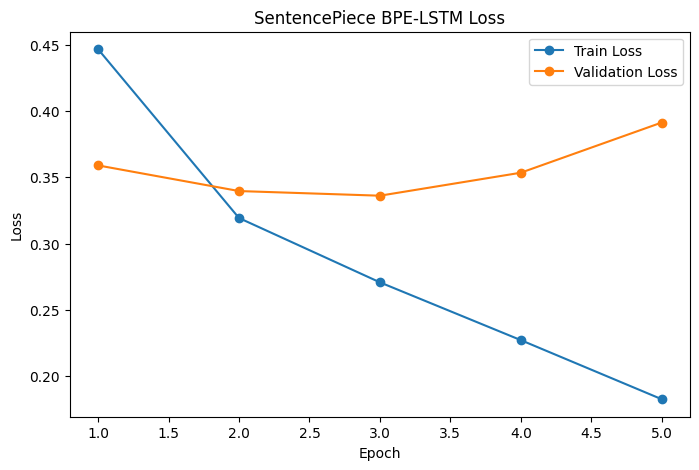

In [85]:
# 학습곡선 Loss
bpe_epochs = range(
    1,
    len(bpe_history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    bpe_epochs,
    bpe_history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    bpe_epochs,
    bpe_history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SentencePiece BPE-LSTM Loss")
plt.legend()
plt.show()

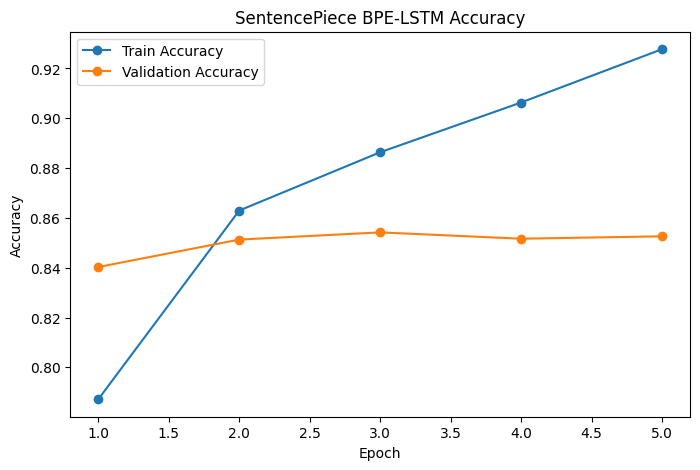

In [86]:
# 학습곡선 accu

plt.figure(figsize=(8, 5))

plt.plot(
    bpe_epochs,
    bpe_history["train_acc"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    bpe_epochs,
    bpe_history["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("SentencePiece BPE-LSTM Accuracy")
plt.legend()
plt.show()

In [87]:
# 딱 1회 테스트
bpe_model.load_state_dict(
    torch.load(
        BPE_BEST_MODEL_PATH,
        map_location=device
    )
)

bpe_test_loss, bpe_test_acc = evaluate(
    bpe_model,
    bpe_test_loader,
    bpe_criterion,
    device
)

print(
    f"BPE Test Loss     : "
    f"{bpe_test_loss:.4f}"
)

print(
    f"BPE Test Accuracy : "
    f"{bpe_test_acc:.4%}"
)

print(
    f"Best Validation Acc : "
    f"{bpe_best_val_acc:.4%}"
)

BPE Test Loss     : 0.3403
BPE Test Accuracy : 85.1558%
Best Validation Acc : 85.4194%


In [92]:
comparison_display = comparison_results.copy()

comparison_display["Avg Tokens"] = (
    comparison_display["Avg Tokens"]
    .map(lambda x: f"{x:.2f}")
)

comparison_display["Coverage@80"] = (
    comparison_display["Coverage@80"]
    .map(lambda x: f"{x:.4%}")
)

comparison_display["Test Token UNK Rate"] = (
    comparison_display["Test Token UNK Rate"]
    .map(lambda x: f"{x:.4%}")
)

comparison_display["Test Sentence UNK Rate"] = (
    comparison_display["Test Sentence UNK Rate"]
    .map(lambda x: f"{x:.2%}")
)

comparison_display["Test Loss"] = (
    comparison_display["Test Loss"]
    .map(lambda x: f"{x:.4f}")
)

comparison_display["Test Accuracy"] = (
    comparison_display["Test Accuracy"]
    .map(lambda x: f"{x:.4%}")
)

comparison_display

,Tokenizer,Vocab Size,Avg Tokens,Coverage@80,Test Token UNK Rate,Test Sentence UNK Rate,Test Loss,Test Accuracy
0,SentencePiece Unigram,8000,17.39,99.6858%,0.1054%,1.61%,0.3533,85.3268%
1,MeCab,8000,18.81,99.8555%,4.6965%,46.21%,0.3397,86.6158%
2,SentencePiece BPE,8000,17.07,99.7683%,0.1075%,1.61%,0.3403,85.1558%


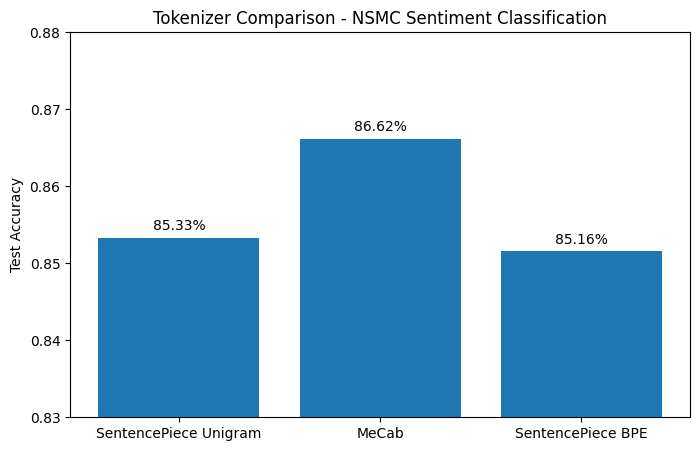

In [93]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_results["Tokenizer"],
    comparison_results["Test Accuracy"]
)

plt.ylabel("Test Accuracy")
plt.title("Tokenizer Comparison - NSMC Sentiment Classification")
plt.ylim(0.83, 0.88)

for i, value in enumerate(
    comparison_results["Test Accuracy"]
):
    plt.text(
        i,
        value + 0.001,
        f"{value:.2%}",
        ha="center"
    )

plt.show()

## 최종 결과 및 결론

본 프로젝트에서는 NSMC 영화 리뷰 감성분류를 대상으로
Tokenizer 방식이 동일한 LSTM 분류 모델의 성능에 미치는 영향을 비교하였다.

비교한 Tokenizer는 다음 세 가지이다.

1. SentencePiece Unigram 8K
2. MeCab 형태소 기반 Tokenizer 8K
3. SentencePiece BPE 8K

모든 실험에서 동일한 Train/Validation/Test split과
동일한 LSTM 구조, Vocabulary size, MAX_LEN, Embedding dimension,
Hidden dimension, Batch size, Learning rate 및 Epoch 조건을 유지하였다.

### 분류 성능

- SentencePiece Unigram Test Accuracy: **85.3268%**
- MeCab Test Accuracy: **86.6158%**
- SentencePiece BPE Test Accuracy: **85.1558%**

세 실험 중 MeCab이 가장 높은 Test Accuracy를 기록하였다.

SentencePiece 내부에서 Unigram과 BPE 알고리즘을 변경했을 때의
성능 차이는 상대적으로 작았으며, 한국어 형태소 단위를 명시적으로
사용한 MeCab으로 Tokenizer의 표현 단위를 변경했을 때
더 큰 성능 차이가 나타났다.

### 일반화 관점

본 실험의 Test 결과는 동일한 NSMC 분포의 unseen 데이터에 대한
in-domain generalization을 평가한 것이다.

이 조건에서는 MeCab이 가장 높은 성능을 기록하였다.

반면 SentencePiece는 미등록 문자열을 기존 Subword 조합으로
표현할 수 있어 MeCab보다 매우 낮은 UNK 비율을 보였다.

따라서 신조어, 오타, 고유명사 또는 다른 도메인의 문장처럼
입력 분포가 변화하는 상황에서는 SentencePiece의 Subword 방식이 장점을 가질 가능성이 있다.

그러나 이러한 out-of-domain generalization은 본 프로젝트에서
직접 평가하지 않았으므로 추가 데이터셋을 이용한 실험이 필요하다.